In [2]:
import json
import sqlite3
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, HPacker, TextArea, DrawingArea, AnchoredText
import matplotlib.patches as mpatches

In [3]:
def process_sqlite_report_kernel_only(filePath):
    con = sqlite3.connect(filePath)
    con.row_factory = sqlite3.Row 
    cur = con.cursor()
    query = """
    SELECT
        'kernel' AS activity_type,
        names.value AS name,
        k.start,
        k.end,
        k.end - k.start AS duration,
        k.registersPerThread,
        k.gridX, k.gridY, k.gridZ,
        k.blockX, k.blockY, k.blockZ,
        k.staticSharedMemory, k.dynamicSharedMemory,
        k.localMemoryPerThread, k.localMemoryTotal,
        k.sharedMemoryLimitConfig,
        k.streamId,
        k.deviceId,
        NULL AS bytes,
        NULL AS copyKind,
        NULL as srcKind,
        NULL as dstKind,
        NULL AS memKind          -- new column for memset
    FROM CUPTI_ACTIVITY_KIND_KERNEL AS k
    JOIN StringIds AS names ON k.demangledName = names.id
    
    ORDER BY start;
    """

    cur.execute(query)
    rows = [dict(row) for row in cur.fetchall()]
    return rows

In [4]:
# 50kX50k match matrix for different scenarios (4 warmup runs)
data_matrix = process_sqlite_report_kernel_only("build/Linux-x86_64/pool_matching_joint_matrix_fp16.sqlite")

# fp16 is just to show that it does not matter much
data_normal_fp16 = process_sqlite_report_kernel_only("build_normal/Linux-x86_64/pool_matching_normal_fp16.sqlite")
data_normal_fp32 = process_sqlite_report_kernel_only("build_normal_fp32/Linux-x86_64/pool_matching_normal_fp32.sqlite")

data_matrix_zero_tail = process_sqlite_report_kernel_only("build/Linux-x86_64/fp32_norm_fp16_matrix_match.sqlite") # It's csv: mixed_precision_joint_matrix_.csv

# Better occupancy for normal matching
normal_big_wg = process_sqlite_report_kernel_only("build/Linux-x86_64/match_normal_big_wg_new.sqlite") # csv: match_normal_big_wg.csv
# Better occupancy for matrix matching
# Need to run those for 50kx50k
# OR maybe I don't need these (as they are slower than data_matrix anyways)

# CUDA normal versions
cuda_normal = process_sqlite_report_kernel_only("../popsift/build/Linux-x86_64/cuda-fp32-match.sqlite")
cuda_normal_big_wg = process_sqlite_report_kernel_only("../popsift/build/Linux-x86_64/cuda_normal_big_wg_new.sqlite")


In [5]:
len(data_matrix_zero_tail)

7512

In [6]:
def tensor_replace_names(data):
    pattern = r'\blambda\b'
    for row in data:
        match = re.search(pattern, row["name"])
        if match: 
            row["name"] = "remainder_normal_matching"
        if row["name"] == "Typeinfo name for popsift::Compute_distance_matrix_pre_norm":
            row["name"] = "matrix_matching"
        if row["name"] in ("Typeinfo name for popsift::Compute_squared_norm", "Typeinfo name for popsift::Compute_squared_norm_fp16_transform"):
            row["name"] = "compute_squared_norm"        

In [7]:
tensor_replace_names(data_matrix)
tensor_replace_names(data_matrix_zero_tail)

In [8]:
def tensor_match_time(data, warmup=4):
    start = 0
    # end = 0
    times: list[int] = []
    current_frame = False
    count = 0
    for index, row in enumerate(data):
        if row["name"] == "compute_squared_norm" and not current_frame:
            start = row["start"]
            current_frame = True
        else: 
            current_frame = False
            if index == len(data)- 1:
                count += 1
                if count > warmup:
                    times.append(row["end"] - start)
            else:
                if data[index + 1]["name"] == "compute_squared_norm":
                    count += 1
                    if count > warmup:
                        times.append(row["end"] - start)
    return times

In [9]:
def tensor_only_match_time(data):
    start = 0
    # end = 0
    times: list[int] = []
    current_frame = False
    count = 0
    for index, row in enumerate(data):
        if row["name"] == "compute_squared_norm" and not current_frame:
            # start = row["start"]
            current_frame = True
        else: 
            if current_frame:
                start = row["start"]
            current_frame = False
            if index == len(data)- 1:
                count += 1
                if count > 4:
                    times.append(row["end"] - start)
            else:
                if data[index + 1]["name"] == "compute_squared_norm":
                    count += 1
                    if count > 4:
                        times.append(row["end"] - start)
    return times

In [10]:
def normal_match_time(data, warmup=4):
    times: list[int] = []
    for row in data:
        times.append(row["duration"])
    return times[warmup:]

In [11]:
# TIMES 50Kx50K

# Tensor times:
times_matrix = tensor_match_time(data_matrix)
times_matrix_zero_tail = tensor_match_time(data_matrix_zero_tail)

# Only match tensor match times (not including norm computation):
times_matrix_only_match = tensor_only_match_time(data_matrix)
times_matrix_zero_tail_only_match = tensor_only_match_time(data_matrix_zero_tail)


# Normal times:
times_normal_fp16 = normal_match_time(data_normal_fp16)
times_normal_fp32 = normal_match_time(data_normal_fp32)
times_normal_big_wg = normal_match_time(normal_big_wg)

# CUDA times:
times_cuda_normal = normal_match_time(cuda_normal)
times_cuda_normal_big_wg = normal_match_time(cuda_normal_big_wg)

In [12]:
# Just used for the left and right dimensions which is the same for all above (50Kx50K)
normal_meta = pd.read_csv("build_normal_fp32/Linux-x86_64/matching_normal_fp32_metadata.csv")

In [13]:
def listify(data):
    l = data["l_desc_size"].tolist()[4:]
    r = data["r_desc_size"].tolist()[4:]
    return l, r

In [14]:
left_desc_len, right_desc_len = listify(normal_meta)

In [15]:
def diff(a, b): 
    """a - b (must be same lenght)"""
    diff_list = []
    for i in range(len(a)):
        diff_list.append(a[i] - b[i])
    return diff_list
    
def diff_percent(a, b): 
    """a - b (must be same lenght)"""
    diff_list = []
    for i in range(len(a)):
        diff_list.append(100 * (a[i] - b[i]) / b[i])
    return diff_list

def diff_mult(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append(a[i] / b[i])
    return diff_list

def diff_log2(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append(np.log2(a[i] / b[i]))
    return diff_list

def distance_around_zero(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append((a[i] - b[i])/min(a[i], b[i]))
    return diff_list


def distance_around_zero_max_base(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append((a[i] - b[i])/max(a[i], b[i]))
    return diff_list

In [16]:
matrix_v_1_wg_normal_mult = diff_mult(times_normal_fp32, times_matrix)
sycl_v_cuda_small_wg_mult = diff_mult(times_normal_fp32, times_cuda_normal)

matrix_zero_v_big_wg_sycl_mult = diff_mult(times_normal_big_wg, times_matrix_zero_tail)
matrix_v_matrix_zero_linear = distance_around_zero(times_matrix, times_matrix_zero_tail)
matrix_v_matrix_zero_match_only_linear = distance_around_zero(times_matrix_only_match, times_matrix_zero_tail_only_match)

In [17]:
cuda_v_sycl_small_wg_linear = distance_around_zero(times_cuda_normal, times_normal_fp32)
cuda_v_sycl_small_wg_linear = distance_around_zero(times_cuda_normal, times_normal_fp32)
cuda_v_sycl_big_wg_linear = distance_around_zero(times_cuda_normal_big_wg, times_normal_big_wg)

In [18]:
times_list = []
for i in range(50):
    for j in range (50):
        if i >= 19 and j >= 19:
            # From and including 20,20 so 30 points
            times_list.append(cuda_v_sycl_small_wg_linear[i * 50 + j])

np.array(times_list).mean()
# print(times_list)




np.float64(-0.007962110655903926)

In [19]:
times_matrix[:5]

[519009, 973057, 1448545, 1914369, 2389857]

In [20]:
times_matrix_zero_tail[:5]

[165217, 303746, 442594, 580580, 731012]

In [21]:
times_cuda_normal_big_wg[-5:]

[611788276, 629737590, 640778546, 655569336, 667228022]

In [22]:
times_normal_big_wg[-5:]

[587466536, 601483637, 618604051, 638665086, 650399133]

In [23]:
def scatter_3d_plot(x, y, z, xlabel, ylabel, zlabel, title, error_bar_label, rotate=False):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    if rotate:
        scatter = ax.scatter(y, x, z, c=z, cmap='magma', edgecolor='k')
        ax.set_xlabel(ylabel)
        ax.set_ylabel(xlabel)
    else:
        scatter = ax.scatter(x, y, z, c=z, cmap='magma', edgecolor='k')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

    ax.set_zlabel(zlabel)
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label=error_bar_label)
    plt.tight_layout()

    plt.show()

In [24]:
def heatmap_2d_plot_around_zero(x, y, z, xlabel, ylabel, title, error_bar_label, cmap='seismic'):
    # plt.figure(figsize=(12, 8))

    vmin = np.min(z)
    vmax = np.max(z)
    abs_max = max(abs(vmin), abs(vmax))
    norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    plt.scatter(
        left_desc_len, right_desc_len,
        c=z,
        cmap=cmap,
        norm=norm
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.colorbar(label=error_bar_label)
    # plt.tight_layout()
    plt.show()

In [25]:
def heatmap_2d_plot(x, y, z, xlabel, ylabel, title, error_bar_label, cmap='magma'):
    plt.scatter(
        left_desc_len, right_desc_len,
        c=z,
        cmap=cmap
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.colorbar(label=error_bar_label)
    plt.show()

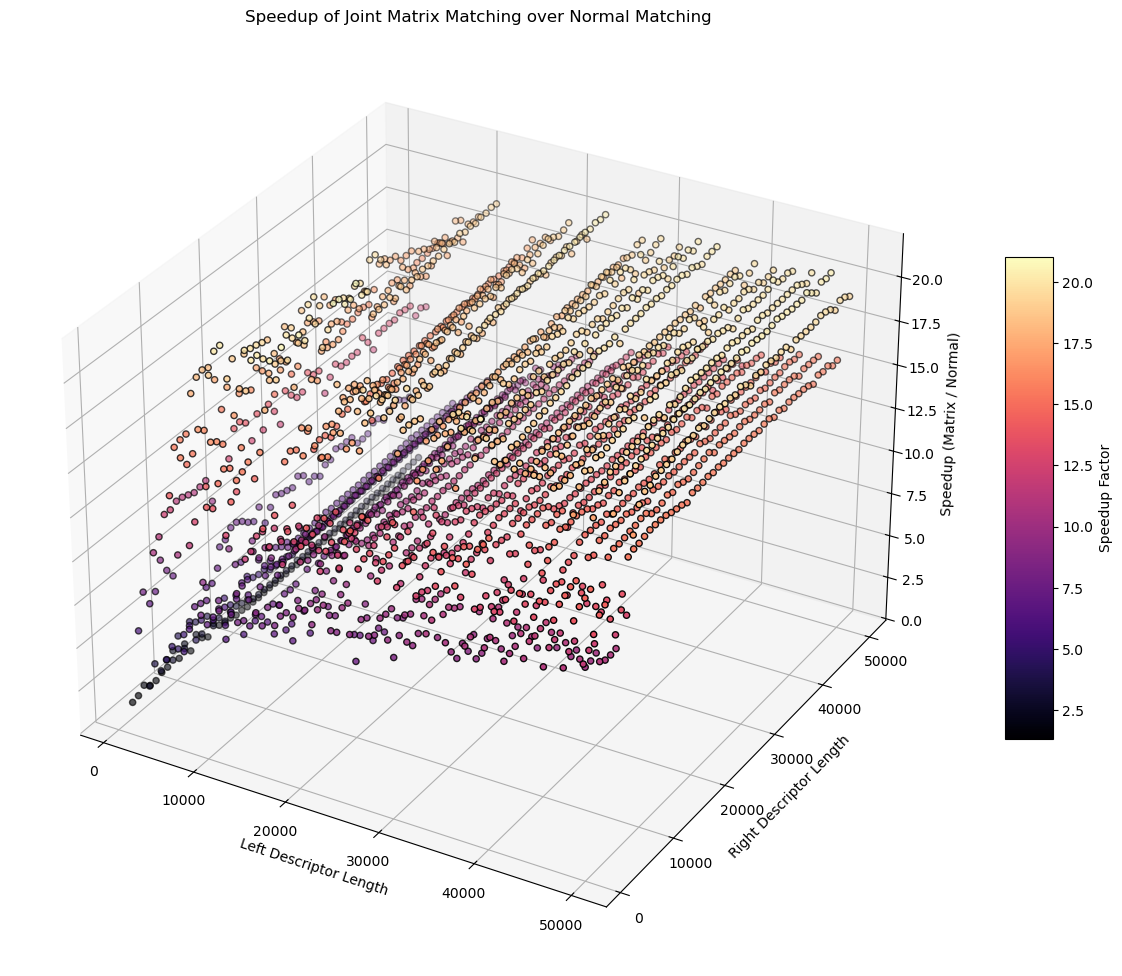

In [26]:
scatter_3d_plot(left_desc_len, right_desc_len, matrix_v_1_wg_normal_mult,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                zlabel='Speedup (Matrix / Normal)',
                title='Speedup of Joint Matrix Matching over Normal Matching',
                error_bar_label='Speedup Factor', 
                rotate=False)

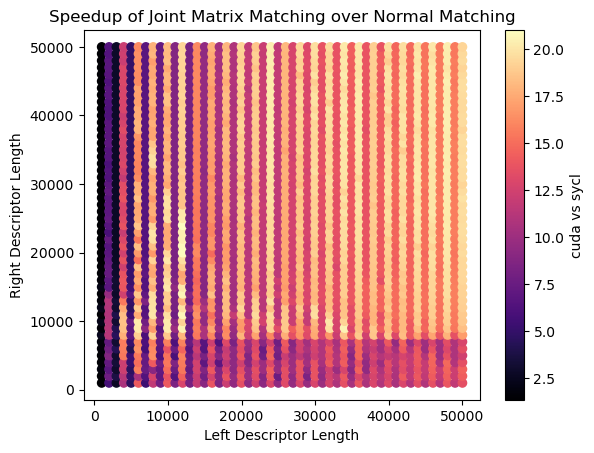

In [27]:
heatmap_2d_plot(left_desc_len, right_desc_len, matrix_v_1_wg_normal_mult,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Speedup of Joint Matrix Matching over Normal Matching',
                error_bar_label='cuda vs sycl')

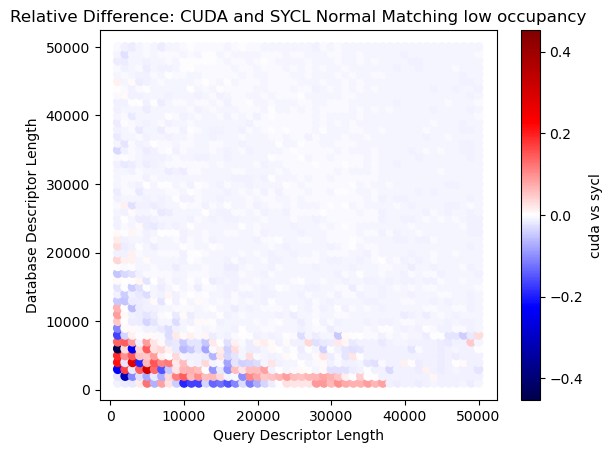

In [28]:
heatmap_2d_plot_around_zero(left_desc_len, right_desc_len, cuda_v_sycl_small_wg_linear,
                xlabel='Query Descriptor Length',
                ylabel='Database Descriptor Length',
                title='Relative Difference: CUDA and SYCL Normal Matching low occupancy',
                error_bar_label='cuda vs sycl')


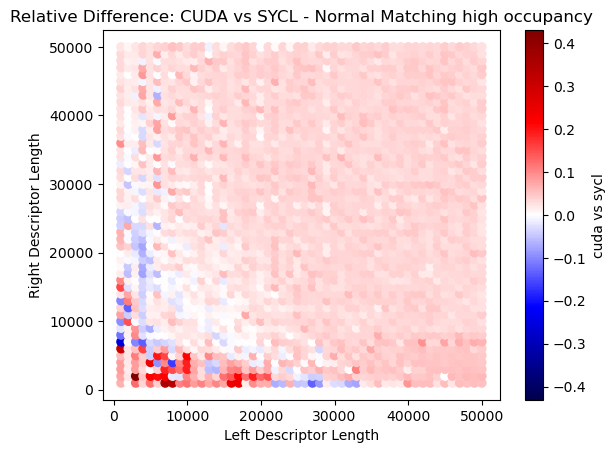

In [29]:
heatmap_2d_plot_around_zero(left_desc_len, right_desc_len, cuda_v_sycl_big_wg_linear,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Relative Difference: CUDA vs SYCL - Normal Matching high occupancy',
                error_bar_label='cuda vs sycl')

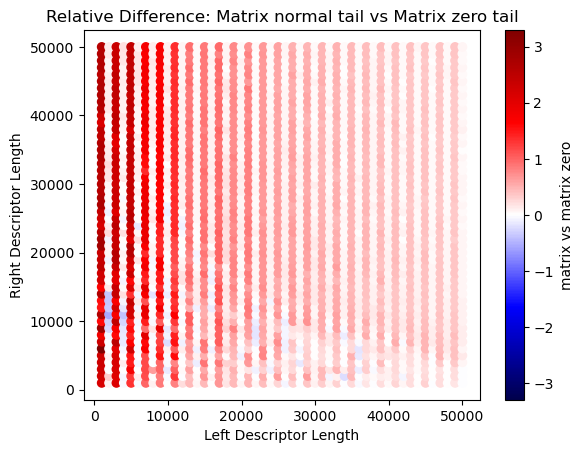

In [30]:
heatmap_2d_plot_around_zero(left_desc_len, right_desc_len, matrix_v_matrix_zero_linear,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Relative Difference: Matrix normal tail vs Matrix zero tail',
                error_bar_label='matrix vs matrix zero')

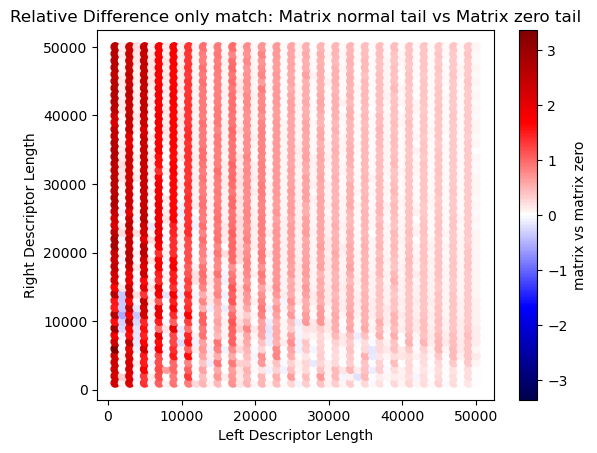

In [31]:

heatmap_2d_plot_around_zero(left_desc_len, right_desc_len, matrix_v_matrix_zero_match_only_linear,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Relative Difference only match: Matrix normal tail vs Matrix zero tail',
                error_bar_label='matrix vs matrix zero')

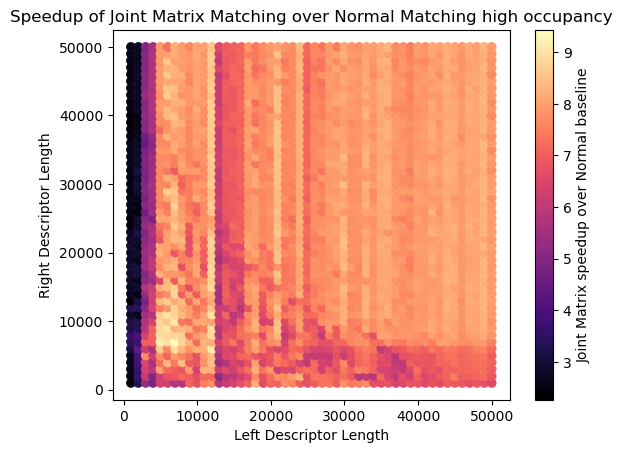

In [32]:
# Good matrix vs good occupancy normal sycl
heatmap_2d_plot(left_desc_len, right_desc_len, matrix_zero_v_big_wg_sycl_mult,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Speedup of Joint Matrix Matching over Normal Matching high occupancy',
                error_bar_label='Joint Matrix speedup over Normal baseline')

In [33]:
# 1k - 80k lr same with 20 repetations and 10 warmup runs

# SYCL tensor
matrix_lr_same_zero = process_sqlite_report_kernel_only("build/Linux-x86_64/match_matrix_zero_tail_lr_same.sqlite")
matrix_lr_same_1_wg = process_sqlite_report_kernel_only("build/Linux-x86_64/tensor_lr_same_1_sg_per_wg.sqlite")
matrix_lr_same_2_wg = process_sqlite_report_kernel_only("build/Linux-x86_64/tensor_lr_same_2_sg_per_wg.sqlite")
matrix_lr_same_3_wg = process_sqlite_report_kernel_only("build/Linux-x86_64/tensor_lr_same_3_sg_per_wg.sqlite")

 
# SYCL normal
normal_lr_same = process_sqlite_report_kernel_only("build/Linux-x86_64/match_normal_lr_same.sqlite")
normal_lr_same_big_wg = process_sqlite_report_kernel_only("build/Linux-x86_64/match_normal_lr_same_big_wg_new.sqlite")

# CUDA normal
cuda_normal_lr_same = process_sqlite_report_kernel_only("../popsift/build/Linux-x86_64/cuda_normal_lr_same.sqlite")
cuda_normal_lr_same_big_wg = process_sqlite_report_kernel_only("../popsift/build/Linux-x86_64/cuda_normal_lr_same_big_wg_new.sqlite")



In [34]:
tensor_replace_names(matrix_lr_same_zero)
tensor_replace_names(matrix_lr_same_1_wg)
tensor_replace_names(matrix_lr_same_2_wg)
tensor_replace_names(matrix_lr_same_3_wg)

In [35]:
# Sycl tensor times:
times_matrix_lr_same_zero = tensor_match_time(matrix_lr_same_zero, 10)
times_matrix_lr_same_1_wg = tensor_match_time(matrix_lr_same_1_wg, 10)
times_matrix_lr_same_2_wg = tensor_match_time(matrix_lr_same_2_wg, 10)
times_matrix_lr_same_3_wg = tensor_match_time(matrix_lr_same_3_wg, 10)

# SYCL normal
times_normal_lr_same = normal_match_time(normal_lr_same, 10)
times_normal_lr_same_big_wg = normal_match_time(normal_lr_same_big_wg, 10)

# CUDA normal
times_cuda_normal_lr_same = normal_match_time(cuda_normal_lr_same, 10)
times_cuda_normal_lr_same_big_wg = normal_match_time(cuda_normal_lr_same_big_wg, 10)

In [36]:
# Only care about lenght so use the same for all
lr_same_length = pd.read_csv("build/Linux-x86_64/tensor_lr_same_3_sg_per_wg.csv")[10:].reset_index(drop=True)

In [37]:
lr_same_length

,l_desc_size,r_desc_size,matches
0,1000,1000,130
1,2000,2000,228
2,3000,3000,333
3,4000,4000,405
4,5000,5000,542
...,...,...,...
1595,76000,76000,6050
1596,77000,77000,6321
1597,78000,78000,6258
1598,79000,79000,6471


In [38]:
def mean_std_compute(data):
    data_ms = [x / 1000000 for x in data]  # Convert to ms
    mean = []
    std = []
    for i in range(80):
        vals = []
        for j in range(20):
            vals.append(data_ms[i + j*80])

        mean.append(np.mean(vals))
        std.append(np.std(vals))
    return mean, std

In [39]:
mean_matrix_lr_zero, std_matrix_lr_zero = mean_std_compute(times_matrix_lr_same_zero)
mean_matrix_lr_1_wg, std_matrix_lr_1_wg = mean_std_compute(times_matrix_lr_same_1_wg)
mean_matrix_lr_2_wg, std_matrix_lr_2_wg = mean_std_compute(times_matrix_lr_same_2_wg)
mean_matrix_lr_3_wg, std_matrix_lr_3_wg = mean_std_compute(times_matrix_lr_same_3_wg)   

mean_normal_lr_same, std_normal_lr_same = mean_std_compute(times_normal_lr_same)
mean_normal_lr_same_big_wg, std_normal_lr_same_big_wg = mean_std_compute(times_normal_lr_same_big_wg)

mean_cuda_normal_lr_same, std_cuda_normal_lr_same = mean_std_compute(times_cuda_normal_lr_same)
mean_cuda_normal_lr_same_big_wg, std_cuda_normal_lr_same_big_wg = mean_std_compute(times_cuda_normal_lr_same_big_wg)

In [40]:
for i in range(80):
    print(f"{lr_same_length['l_desc_size'][i]}, Matrix: {mean_matrix_lr_zero[i]:.4f} ± {std_matrix_lr_zero[i]:.4f}, Matrix 3 WG: {mean_matrix_lr_3_wg[i]:.4f} ± {std_matrix_lr_3_wg[i]:.4f}, Normal SYCL: {mean_normal_lr_same[i]:.4f} ± {std_normal_lr_same[i]:.4f}, Normal SYCL big WG: {mean_normal_lr_same_big_wg[i]:.4f} ± {std_normal_lr_same_big_wg[i]:.4f}, Normal CUDA: {mean_cuda_normal_lr_same[i]:.4f} ± {std_cuda_normal_lr_same[i]:.4f}, Normal CUDA big WG: {mean_cuda_normal_lr_same_big_wg[i]:.4f} ± {std_cuda_normal_lr_same_big_wg[i]:.4f}")
    

1000, Matrix: 0.1764 ± 0.0034, Matrix 3 WG: 0.1705 ± 0.0023, Normal SYCL: 0.7297 ± 0.0030, Normal SYCL big WG: 0.3903 ± 0.0013, Normal CUDA: 0.7269 ± 0.0330, Normal CUDA big WG: 0.4195 ± 0.0023
2000, Matrix: 0.3211 ± 0.0050, Matrix 3 WG: 0.3053 ± 0.0064, Normal SYCL: 2.8481 ± 0.2533, Normal SYCL big WG: 1.1633 ± 0.0018, Normal CUDA: 2.5693 ± 0.0985, Normal CUDA big WG: 1.1851 ± 0.0030
3000, Matrix: 0.4887 ± 0.0618, Matrix 3 WG: 0.5063 ± 0.0117, Normal SYCL: 4.6078 ± 0.2036, Normal SYCL big WG: 3.0712 ± 0.1179, Normal CUDA: 4.8253 ± 0.2235, Normal CUDA big WG: 3.4670 ± 0.0995
4000, Matrix: 0.7508 ± 0.0812, Matrix 3 WG: 0.7054 ± 0.0775, Normal SYCL: 10.4315 ± 0.5883, Normal SYCL big WG: 4.2238 ± 0.0220, Normal CUDA: 10.2666 ± 0.4732, Normal CUDA big WG: 4.4020 ± 0.0653
5000, Matrix: 1.0317 ± 0.0197, Matrix 3 WG: 1.2684 ± 0.0177, Normal SYCL: 14.6626 ± 0.7178, Normal SYCL big WG: 8.7161 ± 0.2912, Normal CUDA: 14.7296 ± 0.5217, Normal CUDA big WG: 9.7242 ± 0.2357
6000, Matrix: 1.3195 ± 0.0

# Statistical Significance 

In [41]:
methods = [
    'times_matrix_lr_same_zero',
    'times_matrix_lr_same_2_wg',
    'times_matrix_lr_same_3_wg',
    'times_normal_lr_same',
    'times_normal_lr_same_big_wg',
    'times_cuda_normal_lr_same',
    'times_cuda_normal_lr_same_big_wg',
]

cases, run, method = [], [], []

for m in methods:
    for j in range(20):
        for x in range(80):
            cases.append(x*1000 + 1000)
            run.append(j)
            method.append(m)

In [42]:
# For statistical significance stuff
data = pd.DataFrame({
    'Case': cases,
    'Method': method,
    'Run': run,
    'Time': np.concatenate([
        times_matrix_lr_same_zero,
        times_matrix_lr_same_2_wg,
        times_matrix_lr_same_3_wg,
        times_normal_lr_same,
        times_normal_lr_same_big_wg,
        times_cuda_normal_lr_same,
        times_cuda_normal_lr_same_big_wg])
}) # 11200 rows x 4 columns
# data

In [43]:
data_avg = data.groupby(['Case', 'Method'], as_index=False)['Time'].mean()

In [44]:
from scipy.stats import ttest_rel
def compare_methods(data, method_a, method_b, alpha=0.05):
    """
    Perform paired t-tests between two methods across all cases.

    Parameters:
        data (pd.DataFrame): Must have columns ['Case', 'Method', 'Time'].
        method_a (str): Name of the first method.
        method_b (str): Name of the second method.
        alpha (float): Significance level (default=0.05).

    Returns:
        list: p-values for all cases.
    """
    p_values = []

    for case in sorted(data['Case'].unique()):
        a_times = data[(data['Case'] == case) & (data['Method'] == method_a)]['Time']
        b_times = data[(data['Case'] == case) & (data['Method'] == method_b)]['Time']

        if len(a_times) == len(b_times) and len(a_times) > 1:
            t, p = ttest_rel(a_times, b_times)
            p_values.append(p)
        else:
            p_values.append(np.nan)  # Handle missing or mismatched samples

    # Summary
    valid_p = [p for p in p_values if not np.isnan(p)]
    significant = sum(p < alpha for p in valid_p)
    # print(f"\nComparison: {method_a} vs {method_b}")
    # print(f"{significant} out of {len(valid_p)} cases show a significant difference (p < {alpha}).\n")

    # Per-case details
    # for i, p in enumerate(p_values):
    #     if np.isnan(p):
    #         print(f"Case {i}: Missing data.")
    #     else:
    #         status = "Significant" if p < alpha else "Not Significant"
    #         print(f"Case {i}: p = {p:.4g} --> {status}")

    return p_values

# Showing the results for the 80 cases with 20 samples

In [ ]:
p_vals_cuda_v_sycl_low_o = compare_methods(data, 'times_cuda_normal_lr_same', 'times_normal_lr_same', 0.01)
p_vals_cuda_v_sycl_high_o = compare_methods(data, 'times_cuda_normal_lr_same_big_wg', 'times_normal_lr_same_big_wg')



In [46]:
nvidia_color = "#76b900"
intel_color = "#00C7FD"
intel_color_dark = "#0068B5"

In [47]:
x_scatter = lr_same_length['l_desc_size'].unique()

In [48]:
p_vals_cuda_v_sycl_low_o = compare_methods(data, 'times_cuda_normal_lr_same', 'times_normal_lr_same', 0.01)

In [49]:
p_vals_cuda_v_sycl_low_o

[np.float64(0.7004979523197381),
 np.float64(0.0002638346718288442),
 np.float64(0.012147092733680654),
 np.float64(0.21501777716980486),
 np.float64(0.7227386192737594),
 np.float64(0.7932401635872235),
 np.float64(0.24794166993258548),
 np.float64(0.5211799856006738),
 np.float64(2.0041438199796954e-05),
 np.float64(0.0006019762865934526),
 np.float64(1.0950895214300117e-05),
 np.float64(1.5290555372826204e-09),
 np.float64(6.761935777147168e-07),
 np.float64(1.209213561929173e-07),
 np.float64(9.885992438418854e-09),
 np.float64(8.907188858516688e-07),
 np.float64(2.1303199634794634e-10),
 np.float64(5.081435549775713e-11),
 np.float64(2.9608176071022565e-12),
 np.float64(1.0565093125204869e-09),
 np.float64(4.1852553254578395e-11),
 np.float64(1.416578400136969e-12),
 np.float64(8.230931977878127e-10),
 np.float64(3.690367597615313e-13),
 np.float64(9.042697734810051e-14),
 np.float64(2.73747803105783e-13),
 np.float64(8.132044127070281e-13),
 np.float64(3.674515591891435e-07),
 np

In [50]:
def significance_color(p, opacity=0.20):
    if p < 0.01:
        return (0.6, 1.0, 0.6, 0.0)   # light green → significant
    elif p < 0.05:
        return (1.0, 1.0, 0.6, opacity)   # light yellow → moderate
    else:
        return (1.0, 0.7, 0.7, opacity)   # light red/pink → not significant

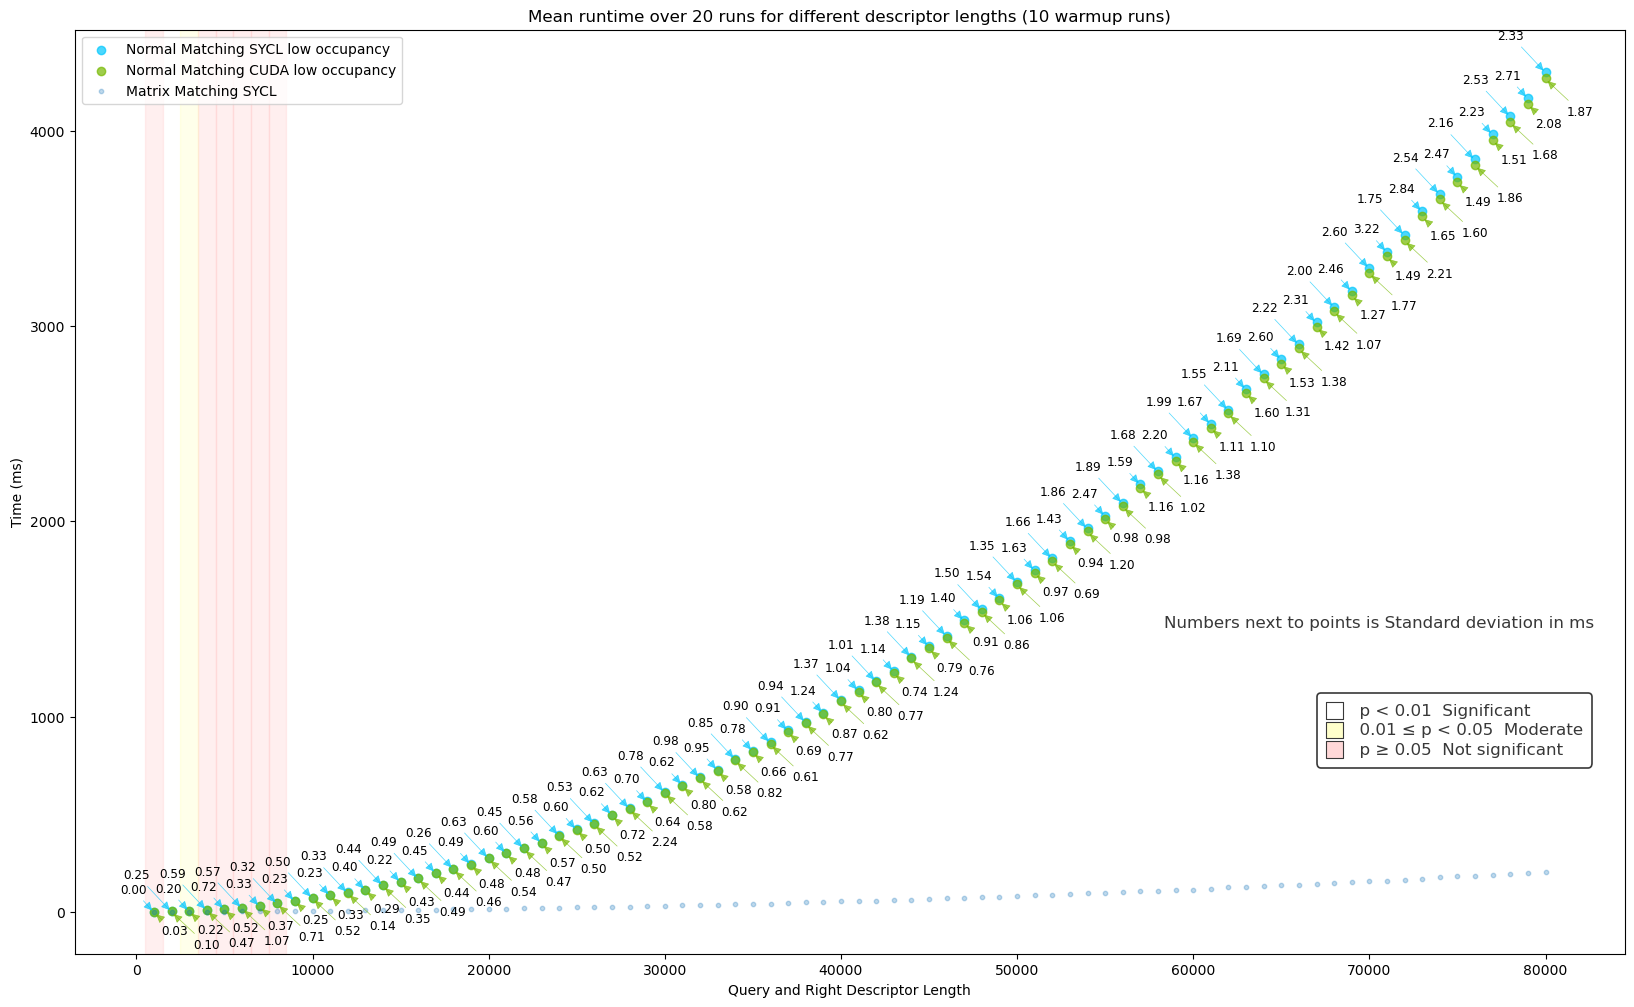

In [51]:
# scatter normal vs normal with std annotated
from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, HPacker, TextArea, DrawingArea, AnchoredText
import matplotlib.patches as mpatches


font_size_dots = 8.7
font_size_info = 12
color_info = "#383838"

plt.figure(figsize=(20, 12))
for xi, p in zip(x_scatter, p_vals_cuda_v_sycl_low_o):
    color = significance_color(p)
    plt.axvspan(xi - 500, xi + 500, color=color, zorder=0)


def color_square(color, edgecolor=color_info, linewidth=0.8):
    da = DrawingArea(12, 12)
    da.add_artist(
        mpatches.Rectangle(
            (0, 0), 12, 12,
            fc=color,
            ec=edgecolor,      
            lw=linewidth,     
            joinstyle='round'  
        )
    )
    return da

box_opacity = 0.5
green_box = color_square(significance_color(0.0001, box_opacity))
yellow_box = color_square(significance_color(0.02, box_opacity))
red_box = color_square(significance_color(0.1, box_opacity))

box = VPacker(children=[
    HPacker(children=[green_box, TextArea("  p < 0.01  Significant", textprops={'color': color_info, 'fontsize': font_size_info})], align="center", pad=0, sep=4),
    HPacker(children=[yellow_box, TextArea("  0.01 ≤ p < 0.05  Moderate", textprops={'color': color_info, 'fontsize': font_size_info})], align="center", pad=0, sep=4),
    HPacker(children=[red_box, TextArea("  p ≥ 0.05  Not significant", textprops={'color': color_info, 'fontsize': font_size_info})], align="center", pad=0, sep=4)
], align="left", pad=0, sep=2)

anchored_box = AnchoredOffsetbox(loc='lower right', child=box, pad=0.4,
                                 frameon=True, bbox_to_anchor=(0.98, 0.20),
                                 bbox_transform=plt.gca().transAxes,
                                 borderpad=0.4)
frame = anchored_box.patch
frame.set_edgecolor(color_info)
frame.set_linewidth(1.2)
frame.set_facecolor('white')
frame.set_alpha(1)
frame.set_boxstyle("round,pad=0.3")
plt.gca().add_artist(anchored_box)


plt.scatter(x_scatter, mean_normal_lr_same, label='Normal Matching SYCL low occupancy', color=intel_color, alpha=0.7)
plt.scatter(x_scatter, mean_cuda_normal_lr_same, label='Normal Matching CUDA low occupancy', color=nvidia_color, alpha=0.7)
plt.scatter(x_scatter, mean_matrix_lr_zero, label='Matrix Matching SYCL', color=intel_color_dark, alpha=0.25, s=10)




plt.text(0.98, 0.35,
         'Numbers next to points is Standard deviation in ms',
         transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=font_size_info, color=color_info)


offsets = [(15, -15), (25, -25)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_cuda_normal_lr_same, std_cuda_normal_lr_same), offsets):
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi - 5), 
        textcoords="offset points", 
        xytext=(dx,dy - 3),
        ha='center', 
        va='bottom',
        fontsize=font_size_dots,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
    )


offsets_sycl = [(-15, 15), (-25, 25)]
offsets_sycl = (offsets_sycl * ((len(x_scatter) // len(offsets_sycl)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_normal_lr_same, std_normal_lr_same), offsets_sycl):
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi - 5), 
        textcoords="offset points", 
        xytext=(dx,dy - 3),
        ha='center', 
        va='bottom',
        fontsize=font_size_dots,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color, lw=0.5, alpha=0.7)
    )

plt.xlabel('Query and Right Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

<Figure size 1200x1000 with 0 Axes>

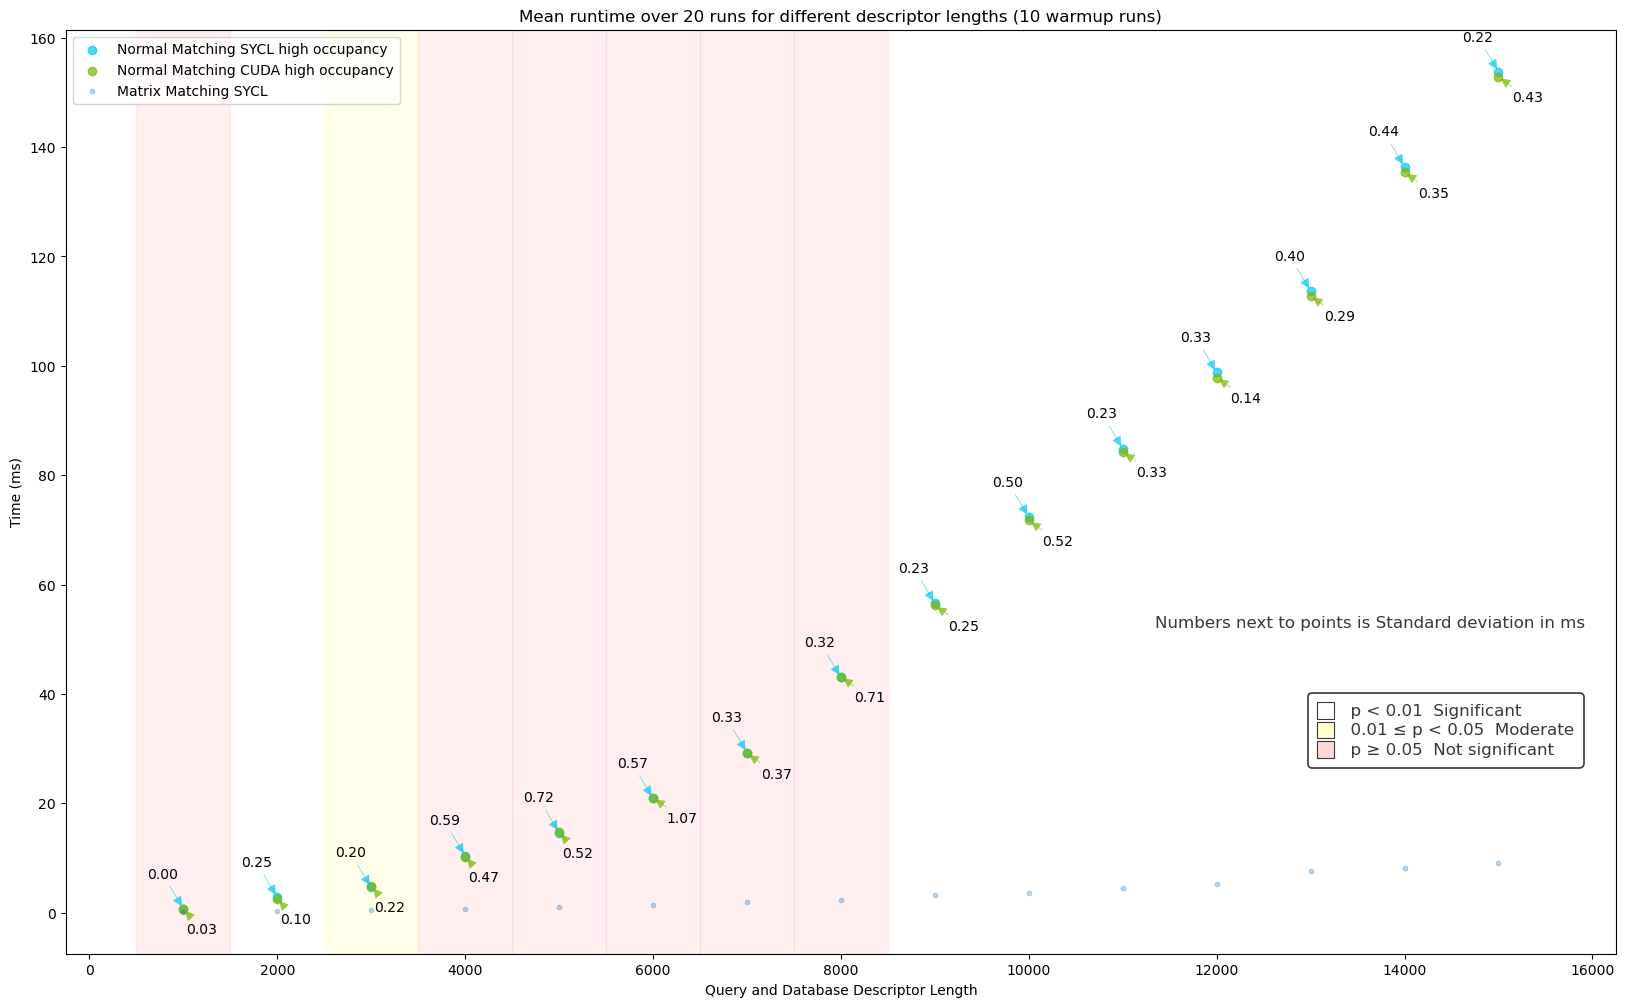

In [52]:
# Only plot first 20 (zoom in)

num = 15
font_size_dots = 10
font_size_info = 12
color_info = "#383838"


plt.figure(figsize=(12, 10))


plt.figure(figsize=(20, 12))
for xi, p in zip(x_scatter, p_vals_cuda_v_sycl_low_o[:num]):
    color = significance_color(p)
    plt.axvspan(xi - 500, xi + 500, color=color, zorder=0)


def color_square(color, edgecolor=color_info, linewidth=0.8):
    da = DrawingArea(12, 12)
    da.add_artist(
        mpatches.Rectangle(
            (0, 0), 12, 12,
            fc=color,
            ec=edgecolor,      
            lw=linewidth,     
            joinstyle='round'  
        )
    )
    return da

box_opacity = 0.5
green_box = color_square(significance_color(0.0001, box_opacity))
yellow_box = color_square(significance_color(0.02, box_opacity))
red_box = color_square(significance_color(0.1, box_opacity))

box = VPacker(children=[
    HPacker(children=[green_box, TextArea("  p < 0.01  Significant", textprops={'color': color_info, 'fontsize': font_size_info})], align="center", pad=0, sep=4),
    HPacker(children=[yellow_box, TextArea("  0.01 ≤ p < 0.05  Moderate", textprops={'color': color_info, 'fontsize': font_size_info})], align="center", pad=0, sep=4),
    HPacker(children=[red_box, TextArea("  p ≥ 0.05  Not significant", textprops={'color': color_info, 'fontsize': font_size_info})], align="center", pad=0, sep=4)
], align="left", pad=0, sep=2)

anchored_box = AnchoredOffsetbox(loc='lower right', child=box, pad=0.4,
                                 frameon=True, bbox_to_anchor=(0.98, 0.20),
                                 bbox_transform=plt.gca().transAxes,
                                 borderpad=0.4)
frame = anchored_box.patch
frame.set_edgecolor(color_info)
frame.set_linewidth(1.2)
frame.set_facecolor('white')
frame.set_alpha(1)
frame.set_boxstyle("round,pad=0.3")
plt.gca().add_artist(anchored_box)


plt.scatter(x_scatter[:num], mean_normal_lr_same[:num], label='Normal Matching SYCL high occupancy', color=intel_color, alpha=0.7)
plt.scatter(x_scatter[:num], mean_cuda_normal_lr_same[:num], label='Normal Matching CUDA high occupancy', color=nvidia_color, alpha=0.7)
plt.scatter(x_scatter[:num], mean_matrix_lr_zero[:num], label='Matrix Matching SYCL', color=intel_color_dark, alpha=0.25, s=10)


plt.text(0.98, 0.35,
         'Numbers next to points is Standard deviation in ms',
         transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=font_size_info, color=color_info)

offsets_cuda = [(18, -15)]
offsets_cuda = (offsets_cuda * ((len(x_scatter) // len(offsets_cuda)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_cuda_normal_lr_same[:num], std_cuda_normal_lr_same[:num]), offsets_cuda):
    if xi > 5000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx+3,dy-5),
            ha='center', 
            va='bottom',
            fontsize=font_size_dots,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )
    else:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx-5,dy-5),
            ha='center', 
            va='bottom',
            fontsize=font_size_dots,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )

# offsets_sycl = [(15, -10), (30, -20)]
# offsets_sycl = [(11, -11), (18, -18)]
# offsets_sycl = [(15, -15)]
offsets_sycl = [(-15, 15)]
offsets_sycl = (offsets_sycl * ((len(x_scatter) // len(offsets_sycl)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_normal_lr_same[:num], std_normal_lr_same[:num]), offsets_sycl):
    # if xi > 3000:
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi), 
        textcoords="offset points", 
        xytext=(dx,dy+5),
        ha='center', 
        va='bottom',
        fontsize=font_size_dots,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color, lw=0.5, alpha=0.7)
    )

plt.xlabel('Query and Database Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

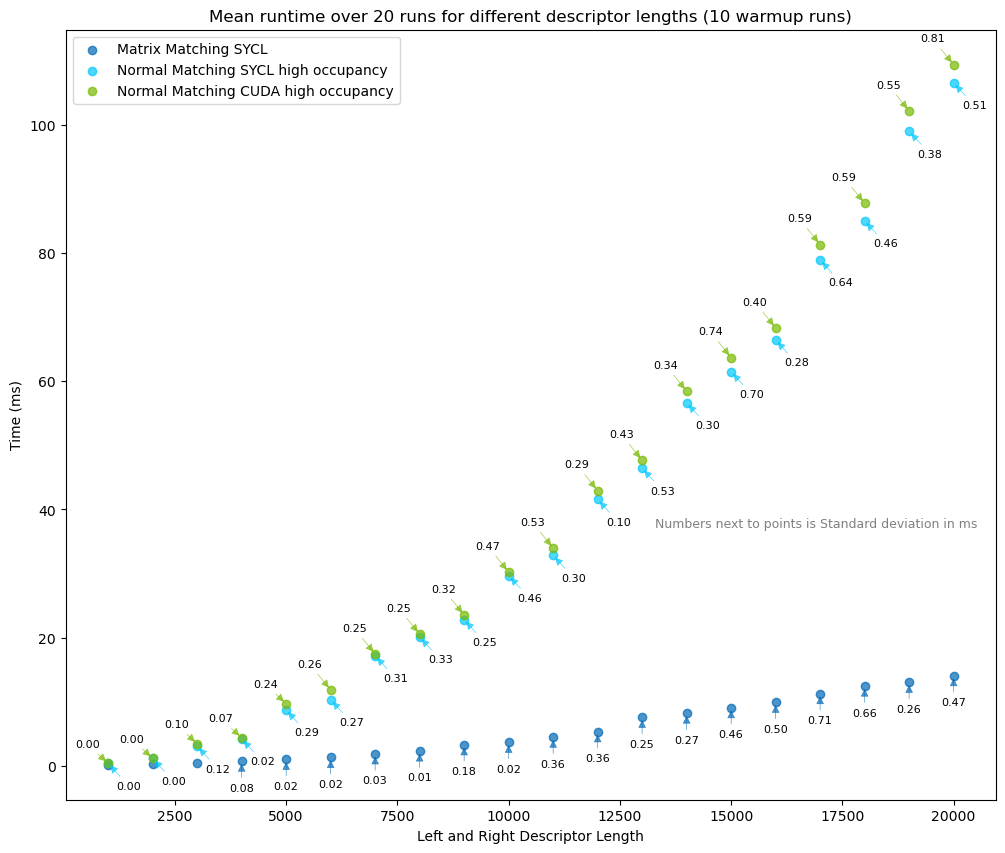

In [53]:
# Only plot first 20 (zoom in)


plt.figure(figsize=(12, 10))
plt.scatter(x_scatter[:20], mean_matrix_lr_zero[:20], label='Matrix Matching SYCL', color=intel_color_dark, alpha=0.7)
plt.scatter(x_scatter[:20], mean_normal_lr_same_big_wg[:20], label='Normal Matching SYCL high occupancy', color=intel_color, alpha=0.7)
plt.scatter(x_scatter[:20], mean_cuda_normal_lr_same_big_wg[:20], label='Normal Matching CUDA high occupancy', color=nvidia_color, alpha=0.7)


plt.text(0.98, 0.35,
         'Numbers next to points is Standard deviation in ms',
         transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=9, color='gray')

# offsets = [(0, -15), (0, -25)]
offsets = [(0, -23)]
offsets = (offsets * ((len(x_scatter[:20]) // len(offsets[:20])) + 1))[:len(x_scatter[:20])]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter[:20], mean_matrix_lr_zero[:20], std_matrix_lr_zero[:20]), offsets):
    if xi > 3000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx,dy),
            ha='center', 
            va='bottom',
            fontsize=8,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color_dark, lw=0.5, alpha=0.7)
        )

# offsets_cuda = [(-15, 10), (-30, 18)]
# offsets_cuda = [(-15, 15), (-20, 20)]
offsets_cuda = [(-15, 15)]
offsets_cuda = (offsets_cuda * ((len(x_scatter) // len(offsets_cuda)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_cuda_normal_lr_same_big_wg[:20], std_cuda_normal_lr_same_big_wg[:20]), offsets_cuda):
    if xi > 5000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx,dy),
            ha='center', 
            va='bottom',
            fontsize=8,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )
    else:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx,dy-5),
            ha='center', 
            va='bottom',
            fontsize=8,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )

# offsets_sycl = [(15, -10), (30, -20)]
# offsets_sycl = [(11, -11), (18, -18)]
offsets_sycl = [(15, -15)]
offsets_sycl = (offsets_sycl * ((len(x_scatter) // len(offsets_sycl)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_normal_lr_same_big_wg[:20], std_normal_lr_same_big_wg[:20]), offsets_sycl):
    # if xi > 3000:
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi), 
        textcoords="offset points", 
        xytext=(dx,dy-5),
        ha='center', 
        va='bottom',
        fontsize=8,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color, lw=0.5, alpha=0.7)
    )

plt.xlabel('Left and Right Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

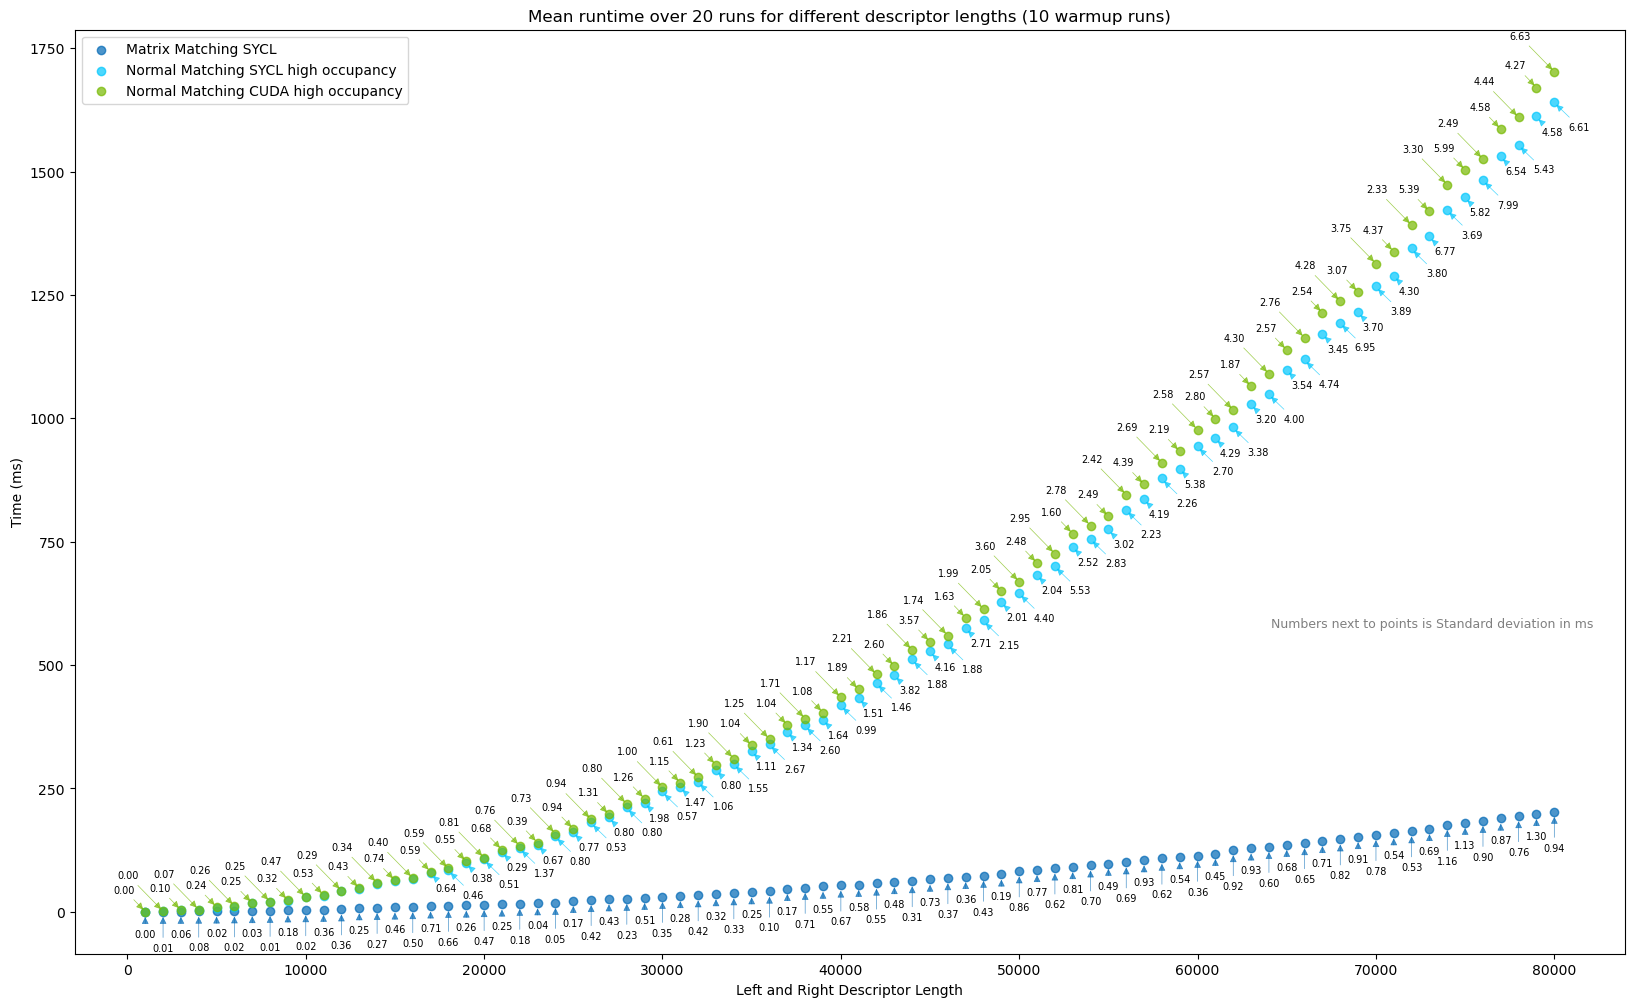

In [54]:
# Scatter plot same data as  above with std annotated for each point 
# plt.figure(figsize=(12, 8))
plt.figure(figsize=(20, 12))
plt.scatter(x_scatter, mean_matrix_lr_zero, label='Matrix Matching SYCL', color=intel_color_dark, alpha=0.7)
plt.scatter(x_scatter, mean_normal_lr_same_big_wg, label='Normal Matching SYCL high occupancy', color=intel_color, alpha=0.7)
plt.scatter(x_scatter, mean_cuda_normal_lr_same_big_wg, label='Normal Matching CUDA high occupancy', color=nvidia_color, alpha=0.7)


plt.text(0.98, 0.35,
         'Numbers next to points is Standard deviation in ms',
         transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=9, color='gray')

offsets = [(0, -15), (0, -25)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_zero, std_matrix_lr_zero), offsets):
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi - 5), 
        textcoords="offset points", 
        xytext=(dx,dy - 3),
        ha='center', 
        va='bottom',
        fontsize=7,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color_dark, lw=0.5, alpha=0.7)
    )

# offsets_cuda = [(-15, 10), (-30, 18)]
offsets_cuda = [(-15, 15), (-25, 25)]
offsets_cuda = (offsets_cuda * ((len(x_scatter) // len(offsets_cuda)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_cuda_normal_lr_same_big_wg, std_cuda_normal_lr_same_big_wg), offsets_cuda):
    if xi > 17000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx,dy-3),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )
    else:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx,dy-3),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )

# offsets_sycl = [(15, -10), (30, -20)]
offsets_sycl = [(11, -11), (18, -18)]
offsets_sycl = (offsets_sycl * ((len(x_scatter) // len(offsets_sycl)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_normal_lr_same_big_wg, std_normal_lr_same_big_wg), offsets_sycl):
    if xi > 16000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi+2, yi-2), 
            textcoords="offset points", 
            xytext=(dx,dy-3),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color, lw=0.5, alpha=0.7)
        )

plt.xlabel('Left and Right Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

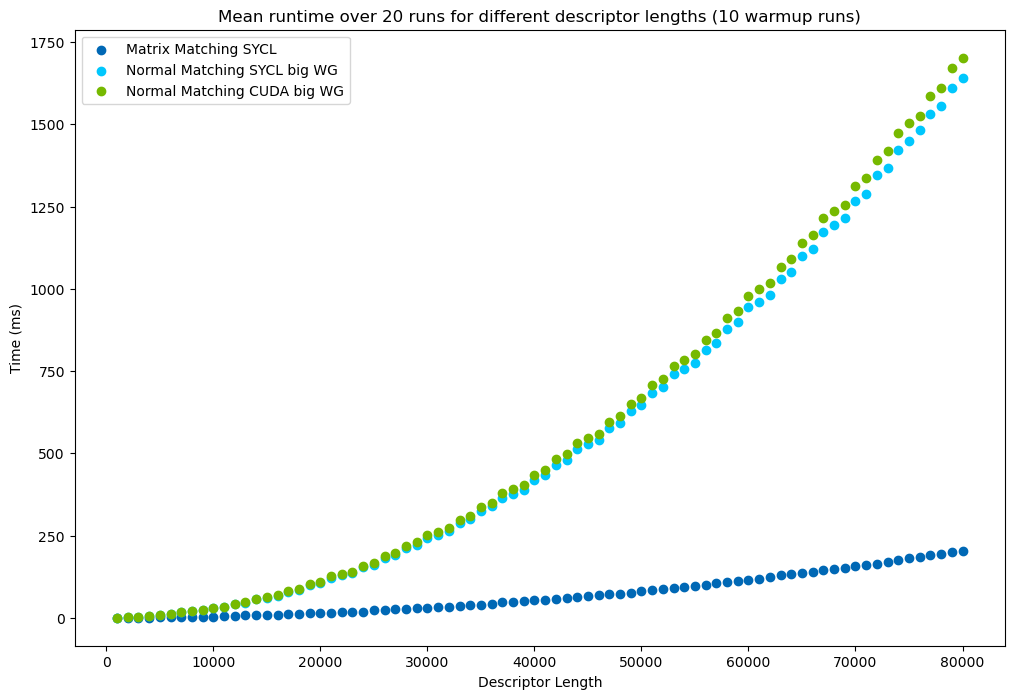

In [55]:
plt.figure(figsize=(12, 8))
plt.scatter(x_scatter, mean_matrix_lr_zero, label='Matrix Matching SYCL', color=intel_color_dark)
plt.scatter(x_scatter, mean_normal_lr_same_big_wg, label='Normal Matching SYCL big WG', color=intel_color)
plt.scatter(x_scatter, mean_cuda_normal_lr_same_big_wg, label='Normal Matching CUDA big WG', color=nvidia_color)
plt.xlabel('Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

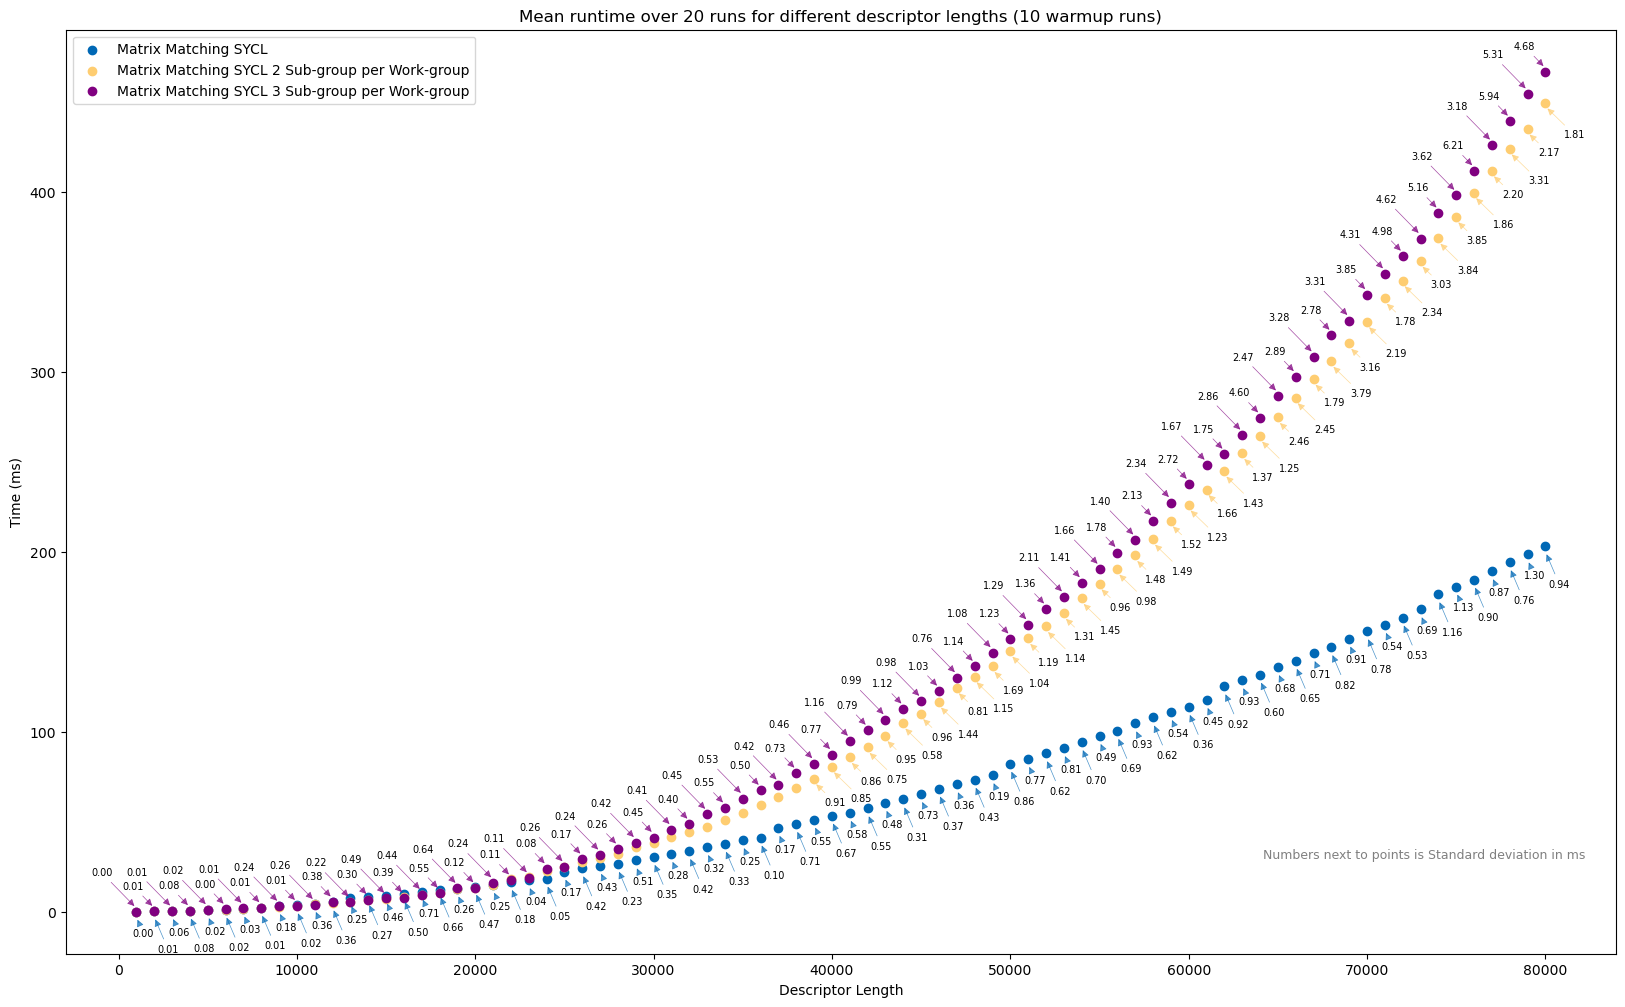

In [56]:

plt.figure(figsize=(20, 12))
plt.scatter(x_scatter, mean_matrix_lr_zero, label='Matrix Matching SYCL', color=intel_color_dark)
plt.scatter(x_scatter, mean_matrix_lr_2_wg, label='Matrix Matching SYCL 2 Sub-group per Work-group', color='#fecd71')
plt.scatter(x_scatter, mean_matrix_lr_3_wg, label='Matrix Matching SYCL 3 Sub-group per Work-group', color='purple')

# Add annotation for the different points
offsets = [(-25, 25), (-15, 15)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_3_wg, std_matrix_lr_3_wg), offsets):
    plt.annotate(
        f'{stdi:.2f}',
        (xi-1, yi+2), 
        textcoords="offset points", 
        xytext=(dx,dy - 3),
        ha='center', 
        va='bottom',
        fontsize=7,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color='purple', lw=0.5, alpha=0.7)
    )

offsets = [(15, -15), (21, -21)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]
for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_2_wg, std_matrix_lr_2_wg), offsets):
    if (xi > 38000):
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi - 2), 
            textcoords="offset points", 
            xytext=(dx,dy - 3),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color='#fecd71', lw=0.5, alpha=0.7)
        )

offsets = [(5, -15), (10, -27)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]
for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_zero, std_matrix_lr_zero), offsets):
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi - 3), 
        textcoords="offset points", 
        xytext=(dx,dy),
        ha='center', 
        va='bottom',
        fontsize=7,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color_dark, lw=0.5, alpha=0.7)
    )


plt.text(0.98, 0.10,
         'Numbers next to points is Standard deviation in ms',
         transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=9, color='gray')


plt.xlabel('Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

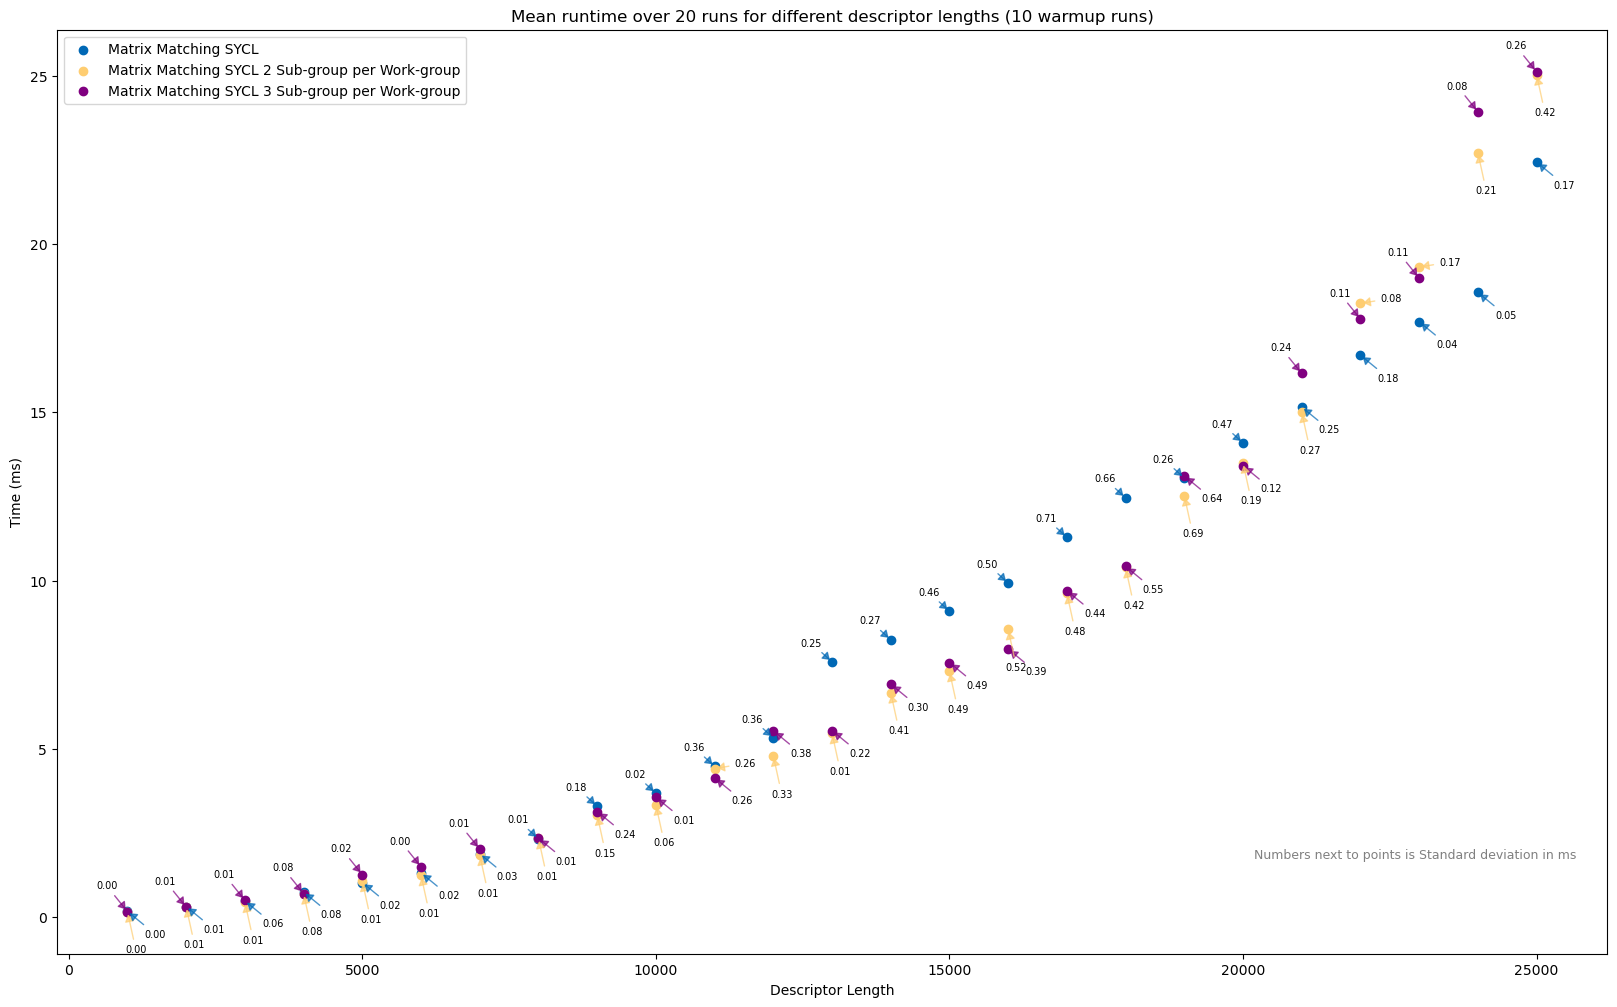

In [57]:
plt.figure(figsize=(20, 12))
plt.scatter(x_scatter[:25], mean_matrix_lr_zero[:25], label='Matrix Matching SYCL', color=intel_color_dark)
plt.scatter(x_scatter[:25], mean_matrix_lr_2_wg[:25], label='Matrix Matching SYCL 2 Sub-group per Work-group', color='#fecd71')
plt.scatter(x_scatter[:25], mean_matrix_lr_3_wg[:25], label='Matrix Matching SYCL 3 Sub-group per Work-group', color='purple')

# Add annotation for the different points
offsets = [(15, -15)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)][:25]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_3_wg[:25], std_matrix_lr_3_wg[:25]), offsets):
    if xi < 8000 or xi > 20000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(-dx,-dy),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.4', color='purple', lw=1, alpha=0.7)
        )
    else:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx+5,dy -5),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.4', color='purple', lw=1, alpha=0.7)
        )

offsets = [(6, -28)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)][:25]
for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_2_wg[:25], std_matrix_lr_2_wg[:25]), offsets):
    if xi in (11000, 22000, 23000):
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(22, 0),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.4', color='#fecd71', lw=1, alpha=0.7)
        )
        continue
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi), 
        textcoords="offset points", 
        xytext=(dx,dy - 3),
        ha='center', 
        va='bottom',
        fontsize=7,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.4', color='#fecd71', lw=1, alpha=0.7)
    )

offsets = [(15, -15)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)][:25]
for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_zero[:25], std_matrix_lr_zero[:25]), offsets):
    if xi < 8000 or xi > 20000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx+5,dy-5),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.4', color=intel_color_dark, lw=1, alpha=0.7)
        )
    else:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(-dx,-dy-5),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.4', color=intel_color_dark, lw=1, alpha=0.7)
        )



plt.text(0.98, 0.10,
         'Numbers next to points is Standard deviation in ms',
         transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=9, color='gray')


plt.xlabel('Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

In [58]:
methods = [
    'times_matrix_lr_same_zero',
    'times_matrix_lr_same_2_wg',
    'times_matrix_lr_same_3_wg',
    'times_normal_lr_same',
    'times_normal_lr_same_big_wg',
    'times_cuda_normal_lr_same',
    'times_cuda_normal_lr_same_big_wg',
]

cases, run, method = [], [], []

for m in methods:
    for j in range(20):
        for x in range(80):
            cases.append(x*1000 + 1000)
            run.append(j)
            method.append(m)


In [59]:
# FOR ANOVA
data = pd.DataFrame({
    'Case': cases,
    'Method': method,
    'Run': run,
    'Time': np.concatenate([
        times_matrix_lr_same_zero,
        times_matrix_lr_same_2_wg,
        times_matrix_lr_same_3_wg,
        times_normal_lr_same,
        times_normal_lr_same_big_wg,
        times_cuda_normal_lr_same,
        times_cuda_normal_lr_same_big_wg])
}) # 11200 rows x 4 columns
data

,Case,Method,Run,Time
0,1000,times_matrix_lr_same_zero,0,165888
1,2000,times_matrix_lr_same_zero,0,310016
2,3000,times_matrix_lr_same_zero,0,445889
3,4000,times_matrix_lr_same_zero,0,700642
4,5000,times_matrix_lr_same_zero,0,1032418
...,...,...,...,...
11195,76000,times_cuda_normal_lr_same_big_wg,19,1528503507
11196,77000,times_cuda_normal_lr_same_big_wg,19,1594669453
11197,78000,times_cuda_normal_lr_same_big_wg,19,1612597608
11198,79000,times_cuda_normal_lr_same_big_wg,19,1668655291


In [60]:

data_avg = data.groupby(['Case', 'Method'], as_index=False)['Time'].mean()
data_avg

,Case,Method,Time
0,1000,times_cuda_normal_lr_same,7.268548e+05
1,1000,times_cuda_normal_lr_same_big_wg,4.195233e+05
2,1000,times_matrix_lr_same_2_wg,1.665689e+05
3,1000,times_matrix_lr_same_3_wg,1.704969e+05
4,1000,times_matrix_lr_same_zero,1.763780e+05
...,...,...,...
555,80000,times_matrix_lr_same_2_wg,4.495711e+08
556,80000,times_matrix_lr_same_3_wg,4.669050e+08
557,80000,times_matrix_lr_same_zero,2.031917e+08
558,80000,times_normal_lr_same,4.302211e+09


In [61]:
import pingouin as pg

anova_results = pg.rm_anova(
    dv='Time',
    within='Method',
    subject='Case',
    data=data_avg,
    detailed=True
)

print(anova_results)

   Source            SS   DF            MS           F         p-unc  \
0  Method  1.731649e+20    6  2.886081e+19  102.136696  3.541703e-82   
1   Error  1.339384e+20  474  2.825705e+17         NaN           NaN   

      p-GG-corr       ng2       eps sphericity       W-spher  p-spher  
0  6.825695e-16  0.358591  0.166704      False  1.755489e-24      0.0  
1           NaN       NaN       NaN        NaN           NaN      NaN  


In [62]:
anova_results = pg.rm_anova(
    dv='Time',
    within='Method',
    subject='Case',
    data=data,
    detailed=True
)

print(anova_results)

   Source            SS   DF            MS           F         p-unc  \
0  Method  1.731649e+20    6  2.886081e+19  102.136696  3.541703e-82   
1   Error  1.339384e+20  474  2.825705e+17         NaN           NaN   

      p-GG-corr       ng2       eps sphericity       W-spher  p-spher  
0  6.825695e-16  0.358591  0.166704      False  1.755489e-24      0.0  
1           NaN       NaN       NaN        NaN           NaN      NaN  


In [63]:
posthoc = pg.pairwise_tests(
    dv='Time',
    within='Method',
    subject='Case',
    data=data_avg,
    padjust='bonf',    # Bonferroni correction
    effsize='hedges'   # effect size type
)

print(posthoc[['A', 'B', 'T', 'p-corr', 'hedges']])

                                   A                                 B  \
0          times_cuda_normal_lr_same  times_cuda_normal_lr_same_big_wg   
1          times_cuda_normal_lr_same         times_matrix_lr_same_2_wg   
2          times_cuda_normal_lr_same         times_matrix_lr_same_3_wg   
3          times_cuda_normal_lr_same         times_matrix_lr_same_zero   
4          times_cuda_normal_lr_same              times_normal_lr_same   
5          times_cuda_normal_lr_same       times_normal_lr_same_big_wg   
6   times_cuda_normal_lr_same_big_wg         times_matrix_lr_same_2_wg   
7   times_cuda_normal_lr_same_big_wg         times_matrix_lr_same_3_wg   
8   times_cuda_normal_lr_same_big_wg         times_matrix_lr_same_zero   
9   times_cuda_normal_lr_same_big_wg              times_normal_lr_same   
10  times_cuda_normal_lr_same_big_wg       times_normal_lr_same_big_wg   
11         times_matrix_lr_same_2_wg         times_matrix_lr_same_3_wg   
12         times_matrix_lr_same_2_wg  

In [64]:
posthoc = pg.pairwise_ttests(
    dv='Time',
    within='Method',
    subject='Case',
    data=data,
    padjust='bonf',  # or 'fdr_bh' for FDR correction
    effsize='cohen'
)
posthoc

/usr/lib/python3.13/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,cohen
0,Method,times_cuda_normal_lr_same,times_cuda_normal_lr_same_big_wg,True,True,9.990428,79.0,two-sided,1.151166e-15,2.417449e-14,bonf,5.692e+12,0.879193
1,Method,times_cuda_normal_lr_same,times_matrix_lr_same_2_wg,True,True,10.170557,79.0,two-sided,5.163801e-16,1.084398e-14,bonf,1.24e+13,1.431717
2,Method,times_cuda_normal_lr_same,times_matrix_lr_same_3_wg,True,True,10.165474,79.0,two-sided,5.281794e-16,1.109177e-14,bonf,1.213e+13,1.424183
3,Method,times_cuda_normal_lr_same,times_matrix_lr_same_zero,True,True,10.022448,79.0,two-sided,9.981207e-16,2.096053e-14,bonf,6.538e+12,1.507464
4,Method,times_cuda_normal_lr_same,times_normal_lr_same,True,True,-10.122756,79.0,two-sided,6.386674e-16,1.341202e-14,bonf,1.009e+13,-0.008638
5,Method,times_cuda_normal_lr_same,times_normal_lr_same_big_wg,True,True,9.990835,79.0,two-sided,1.149079e-15,2.413065e-14,bonf,5.702e+12,0.904020
6,Method,times_cuda_normal_lr_same_big_wg,times_matrix_lr_same_2_wg,True,True,10.529665,79.0,two-sided,1.051297e-16,2.207725e-15,bonf,5.825e+13,1.189512
7,Method,times_cuda_normal_lr_same_big_wg,times_matrix_lr_same_3_wg,True,True,10.519641,79.0,two-sided,1.098913e-16,2.307717e-15,bonf,5.579e+13,1.169822
8,Method,times_cuda_normal_lr_same_big_wg,times_matrix_lr_same_zero,True,True,10.075575,79.0,two-sided,7.878582e-16,1.654502e-14,bonf,8.226e+12,1.393713
9,Method,times_cuda_normal_lr_same_big_wg,times_normal_lr_same,True,True,-9.992253,79.0,two-sided,1.141842e-15,2.397867e-14,bonf,5.737e+12,-0.884739


In [65]:
import pingouin as pg
import numpy as np
from statsmodels.stats.multicomp import MultiComparison

# average per Case per Method (to one row per Case)
avg = data.groupby(['Case','Method'], as_index=False)['Time'].mean()
mc = MultiComparison(avg['Time'], avg['Method'])
letters_df = mc.tukeyhsd().groupsunique  # assign letters if using Tukey


In [66]:
letters = {
    'times_normal_lr_same': 'a',
    'times_normal_lr_same_big_wg': 'b',
    'times_cuda_normal_lr_same': 'b',
    'times_cuda_normal_lr_same_big_wg': 'c',
    'times_matrix_lr_same_zero': 'd',
    'times_matrix_lr_same_2_wg': 'd',
    'times_matrix_lr_same_3_wg': 'e'
}

/tmp/ipykernel_413730/715115174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


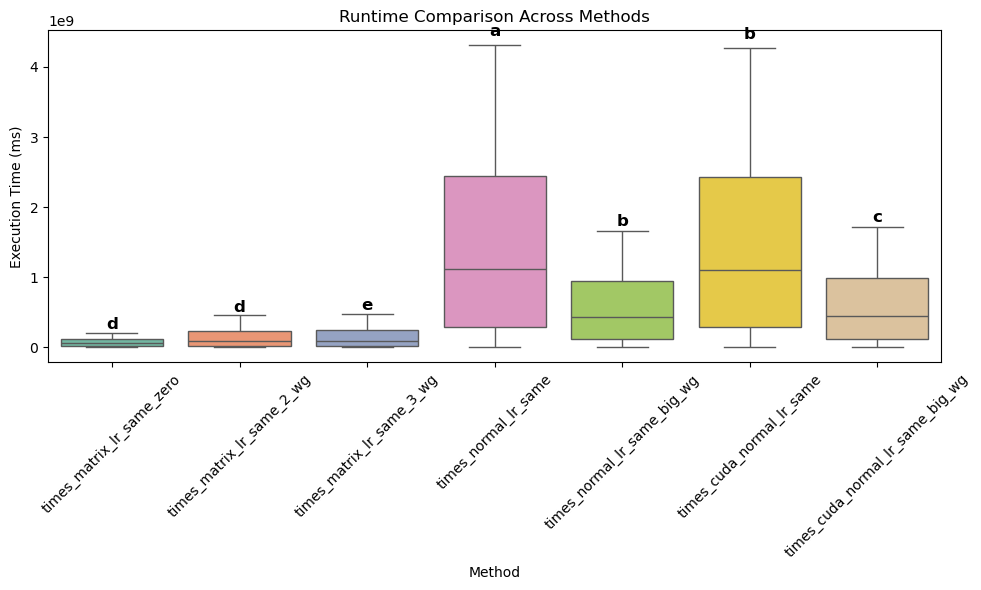

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
ax = sns.boxplot(
    data=data,
    x='Method',
    y='Time',
    palette='Set2',
    showfliers=False
)

# add letters above each box
positions = range(len(data['Method'].unique()))
for pos, method in zip(positions, data['Method'].unique()):
    y = data.loc[data['Method'] == method, 'Time'].max()
    ax.text(pos, y * 1.02, letters[method],
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Runtime Comparison Across Methods')
ax.set_ylabel('Execution Time (ms)')
ax.set_xlabel('Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_413730/804804147.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


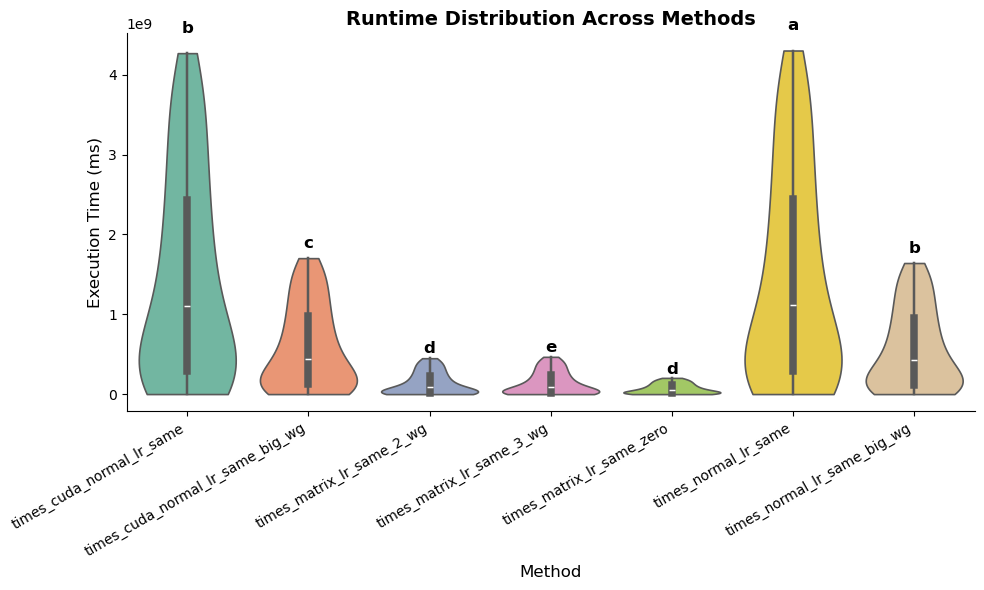

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Example setup (you already have 'data') ---
# data has columns: ['Case', 'Method', 'Run', 'Time']

# Compute per-case means to remove run-level noise
data_case = data.groupby(['Case', 'Method'], as_index=False)['Time'].mean()

# --- Example: post-hoc letters dictionary (replace with real results) ---
letters = {
    'times_normal_lr_same': 'a',
    'times_normal_lr_same_big_wg': 'b',
    'times_cuda_normal_lr_same': 'b',
    'times_cuda_normal_lr_same_big_wg': 'c',
    'times_matrix_lr_same_zero': 'd',
    'times_matrix_lr_same_2_wg': 'd',
    'times_matrix_lr_same_3_wg': 'e'
}

# --- Violin plot ---
plt.figure(figsize=(10,6))
ax = sns.violinplot(
    data=data_case,
    x='Method',
    y='Time',
    inner='box',        # show box inside each violin
    linewidth=1.2,
    cut=0,              # don’t extend beyond data range
    palette='Set2'      # nice, colorblind-safe palette
)

# Add significance letters above each violin
for i, method in enumerate(data_case['Method'].unique()):
    y = data_case.loc[data_case['Method'] == method, 'Time'].max()
    ax.text(i, y * 1.05, letters.get(method, ''),  # slightly above max
            ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='black')

# --- Styling ---
ax.set_title('Runtime Distribution Across Methods', fontsize=14, fontweight='bold')
ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('Execution Time (ms)', fontsize=12)
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

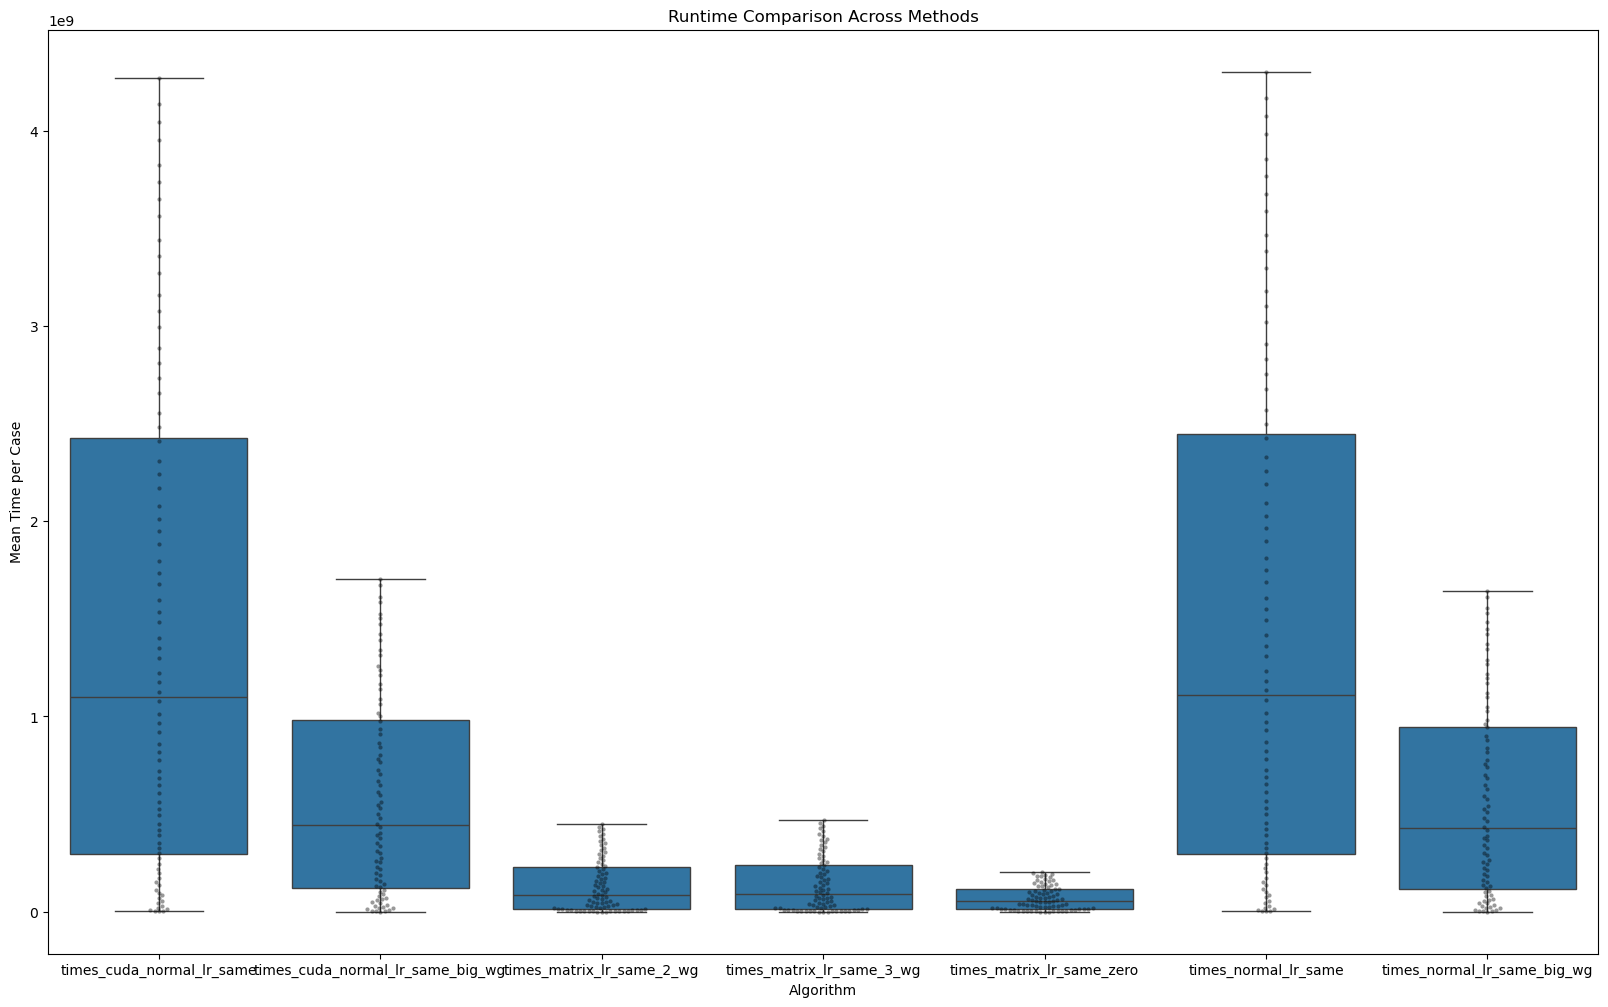

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,12))
sns.boxplot(data=data_avg, x='Method', y='Time')
sns.swarmplot(data=data_avg, x='Method', y='Time', color='black', alpha=0.4, size=3)
plt.title('Runtime Comparison Across Methods')
plt.ylabel('Mean Time per Case')
plt.xlabel('Algorithm')
plt.show()

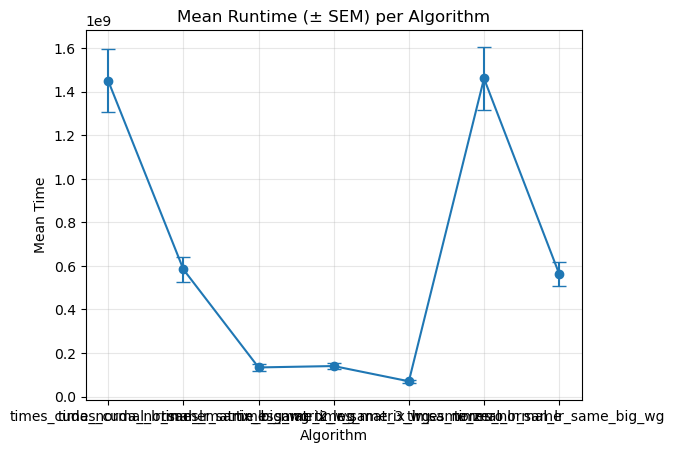

In [70]:
summary = data_avg.groupby('Method')['Time'].agg(['mean', 'sem']).reset_index()

plt.errorbar(summary['Method'], summary['mean'], yerr=summary['sem'], fmt='o-', capsize=5)
plt.title('Mean Runtime (± SEM) per Algorithm')
plt.ylabel('Mean Time')
plt.xlabel('Algorithm')
plt.grid(alpha=0.3)
plt.show()

In [71]:
data_avg.groupby('Method')['Time'].mean()

Method
times_cuda_normal_lr_same           1.448613e+09
times_cuda_normal_lr_same_big_wg    5.836689e+08
times_matrix_lr_same_2_wg           1.338445e+08
times_matrix_lr_same_3_wg           1.402330e+08
times_matrix_lr_same_zero           7.031873e+07
times_normal_lr_same                1.459813e+09
times_normal_lr_same_big_wg         5.634704e+08
Name: Time, dtype: float64

In [72]:
from scipy.stats import ttest_rel
def compare_methods(data, method_a, method_b, alpha=0.05):
    """
    Perform paired t-tests between two methods across all cases.

    Parameters:
        data (pd.DataFrame): Must have columns ['Case', 'Method', 'Time'].
        method_a (str): Name of the first method.
        method_b (str): Name of the second method.
        alpha (float): Significance level (default=0.05).

    Returns:
        list: p-values for all cases.
    """
    p_values = []

    for case in sorted(data['Case'].unique()):
        a_times = data[(data['Case'] == case) & (data['Method'] == method_a)]['Time']
        b_times = data[(data['Case'] == case) & (data['Method'] == method_b)]['Time']

        if len(a_times) == len(b_times) and len(a_times) > 1:
            t, p = ttest_rel(a_times, b_times)
            p_values.append(p)
        else:
            p_values.append(np.nan)  # Handle missing or mismatched samples

    # Summary
    valid_p = [p for p in p_values if not np.isnan(p)]
    significant = sum(p < alpha for p in valid_p)
    print(f"\nComparison: {method_a} vs {method_b}")
    print(f"{significant} out of {len(valid_p)} cases show a significant difference (p < {alpha}).\n")

    # Per-case details
    for i, p in enumerate(p_values):
        if np.isnan(p):
            print(f"Case {i}: Missing data.")
        else:
            status = "Significant" if p < alpha else "Not Significant"
            print(f"Case {i}: p = {p:.4g} --> {status}")

    return p_values

In [73]:
p_vals = compare_methods(data, 'times_cuda_normal_lr_same', 'times_normal_lr_same', 0.01)


Comparison: times_cuda_normal_lr_same vs times_normal_lr_same
73 out of 80 cases show a significant difference (p < 0.01).

Case 0: p = 0.7005 --> Not Significant
Case 1: p = 0.0002638 --> Significant
Case 2: p = 0.01215 --> Not Significant
Case 3: p = 0.215 --> Not Significant
Case 4: p = 0.7227 --> Not Significant
Case 5: p = 0.7932 --> Not Significant
Case 6: p = 0.2479 --> Not Significant
Case 7: p = 0.5212 --> Not Significant
Case 8: p = 2.004e-05 --> Significant
Case 9: p = 0.000602 --> Significant
Case 10: p = 1.095e-05 --> Significant
Case 11: p = 1.529e-09 --> Significant
Case 12: p = 6.762e-07 --> Significant
Case 13: p = 1.209e-07 --> Significant
Case 14: p = 9.886e-09 --> Significant
Case 15: p = 8.907e-07 --> Significant
Case 16: p = 2.13e-10 --> Significant
Case 17: p = 5.081e-11 --> Significant
Case 18: p = 2.961e-12 --> Significant
Case 19: p = 1.057e-09 --> Significant
Case 20: p = 4.185e-11 --> Significant
Case 21: p = 1.417e-12 --> Significant
Case 22: p = 8.231e-10

In [74]:
p_vals = compare_methods(data, 'times_matrix_lr_same_zero', 'times_matrix_lr_same_zero')


Comparison: times_matrix_lr_same_zero vs times_matrix_lr_same_zero
0 out of 0 cases show a significant difference (p < 0.05).

Case 0: Missing data.
Case 1: Missing data.
Case 2: Missing data.
Case 3: Missing data.
Case 4: Missing data.
Case 5: Missing data.
Case 6: Missing data.
Case 7: Missing data.
Case 8: Missing data.
Case 9: Missing data.
Case 10: Missing data.
Case 11: Missing data.
Case 12: Missing data.
Case 13: Missing data.
Case 14: Missing data.
Case 15: Missing data.
Case 16: Missing data.
Case 17: Missing data.
Case 18: Missing data.
Case 19: Missing data.
Case 20: Missing data.
Case 21: Missing data.
Case 22: Missing data.
Case 23: Missing data.
Case 24: Missing data.
Case 25: Missing data.
Case 26: Missing data.
Case 27: Missing data.
Case 28: Missing data.
Case 29: Missing data.
Case 30: Missing data.
Case 31: Missing data.
Case 32: Missing data.
Case 33: Missing data.
Case 34: Missing data.
Case 35: Missing data.
Case 36: Missing data.
Case 37: Missing data.
Case 38:

In [75]:
# Plot statistical significance between
# times_cuda_normal_lr_same           1.448613e+09
# times_cuda_normal_lr_same_big_wg    5.836689e+08
# times_matrix_lr_same_2_wg           1.338445e+08
# times_matrix_lr_same_3_wg           1.402330e+08
# times_matrix_lr_same_zero           7.031873e+07
# times_normal_lr_same                1.459813e+09
# times_normal_lr_same_big_wg         5.634704e+08

p_vals_0 = compare_methods(data, 'times_matrix_lr_same_zero', 'times_normal_lr_same')
p_vals_1 = compare_methods(data, 'times_matrix_lr_same_zero', 'times_cuda_normal_lr_same')
p_vals_2 = compare_methods(data, 'times_matrix_lr_same_zero', 'times_normal_lr_same_big_wg')
p_vals_3 = compare_methods(data, 'times_matrix_lr_same_zero', 'times_cuda_normal_lr_same_big_wg')
p_vals_4 = compare_methods(data, 'times_matrix_lr_same_zero', 'times_matrix_lr_same_2_wg')
p_vals_5 = compare_methods(data, 'times_matrix_lr_same_zero', 'times_matrix_lr_same_3_wg')


Comparison: times_matrix_lr_same_zero vs times_normal_lr_same
80 out of 80 cases show a significant difference (p < 0.05).

Case 0: p = 3.883e-41 --> Significant
Case 1: p = 1.611e-20 --> Significant
Case 2: p = 4.089e-26 --> Significant
Case 3: p = 1.207e-24 --> Significant
Case 4: p = 9.078e-26 --> Significant
Case 5: p = 9.407e-31 --> Significant
Case 6: p = 9.431e-38 --> Significant
Case 7: p = 2.161e-41 --> Significant
Case 8: p = 1.14e-43 --> Significant
Case 9: p = 4.472e-42 --> Significant
Case 10: p = 3.866e-44 --> Significant
Case 11: p = 3.92e-43 --> Significant
Case 12: p = 2.558e-47 --> Significant
Case 13: p = 8.556e-47 --> Significant
Case 14: p = 1.663e-47 --> Significant
Case 15: p = 4.532e-47 --> Significant
Case 16: p = 1.935e-46 --> Significant
Case 17: p = 7.877e-48 --> Significant
Case 18: p = 9.935e-52 --> Significant
Case 19: p = 1.54e-49 --> Significant
Case 20: p = 3.068e-53 --> Significant
Case 21: p = 9.401e-56 --> Significant
Case 22: p = 4.012e-54 --> Sig

In [76]:
baseline = 'times_matrix_lr_same_zero'
comparisons = [
    'times_normal_lr_same',
    'times_cuda_normal_lr_same',
    'times_normal_lr_same_big_wg',
    'times_cuda_normal_lr_same_big_wg',
    'times_matrix_lr_same_2_wg',
    'times_matrix_lr_same_3_wg'
]

cases = sorted(data['Case'].unique())

# Matrix to hold signed significance values
sig_matrix = np.zeros((len(cases), len(comparisons)))

for j, comp in enumerate(comparisons):
    for i, case in enumerate(cases):
        base = data[(data['Case']==case) & (data['Method']==baseline)]['Time']
        other = data[(data['Case']==case) & (data['Method']==comp)]['Time']

        if len(base) == len(other) and len(base) > 1:
            t, p = ttest_rel(base, other)
            diff = np.mean(base) - np.mean(other)
            # Encode direction * significance: sign(diff) * -log10(p)
            sig_matrix[i, j] = np.sign(diff) * -np.log10(p)
        else:
            sig_matrix[i, j] = np.nan  # missing data


sig_df = pd.DataFrame(sig_matrix, index=cases, columns=comparisons)

name_map = {
    'times_normal_lr_same': 'SYCL Low occupancy',
    'times_cuda_normal_lr_same': 'CUDA Low occupancy',
    'times_normal_lr_same_big_wg': 'SYCL High occupancy',
    'times_cuda_normal_lr_same_big_wg': 'CUDA High occupancy',
    'times_matrix_lr_same_2_wg': 'Matrix ~66% occupancy',
    'times_matrix_lr_same_3_wg': 'Matrix ~100% occupancy'
}

sig_df = sig_df.rename(columns=name_map)

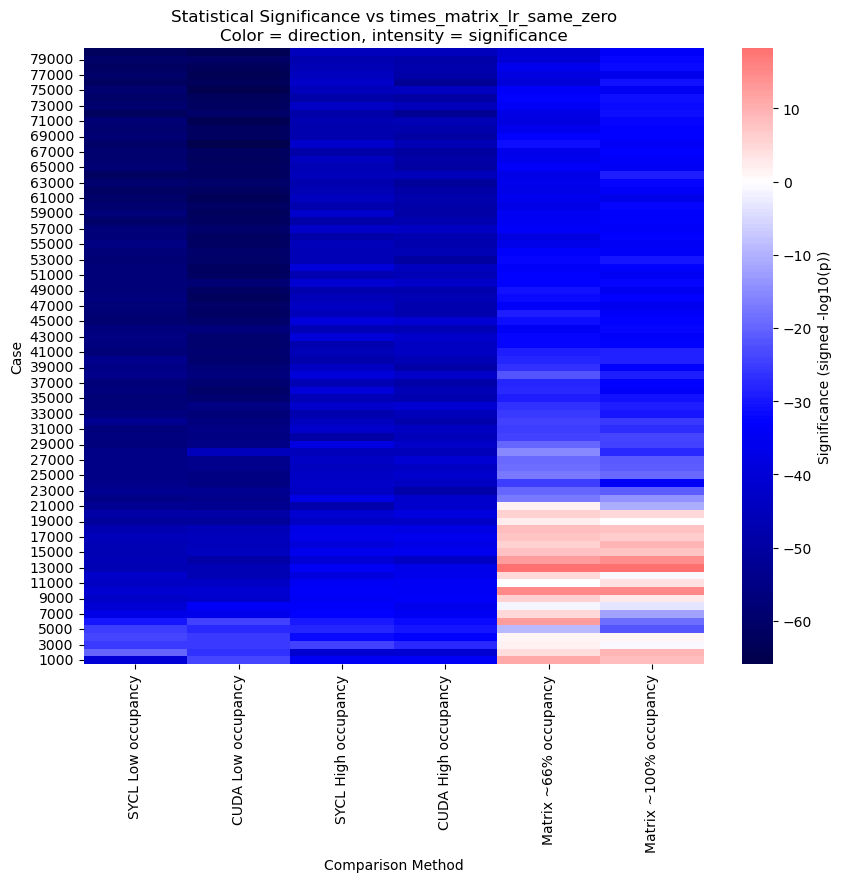

In [77]:

plt.figure(figsize=(10, 8))
sns.heatmap(
    sig_df,
    cmap='seismic',  # red–blue diverging colormap
    center=0,         # 0 means no difference
    cbar_kws={'label': 'Significance (signed -log10(p))'}
)
plt.title(f'Statistical Significance vs {baseline}\nColor = direction, intensity = significance')
plt.xlabel('Comparison Method')
plt.ylabel('Case')
plt.gca().invert_yaxis()
plt.show()

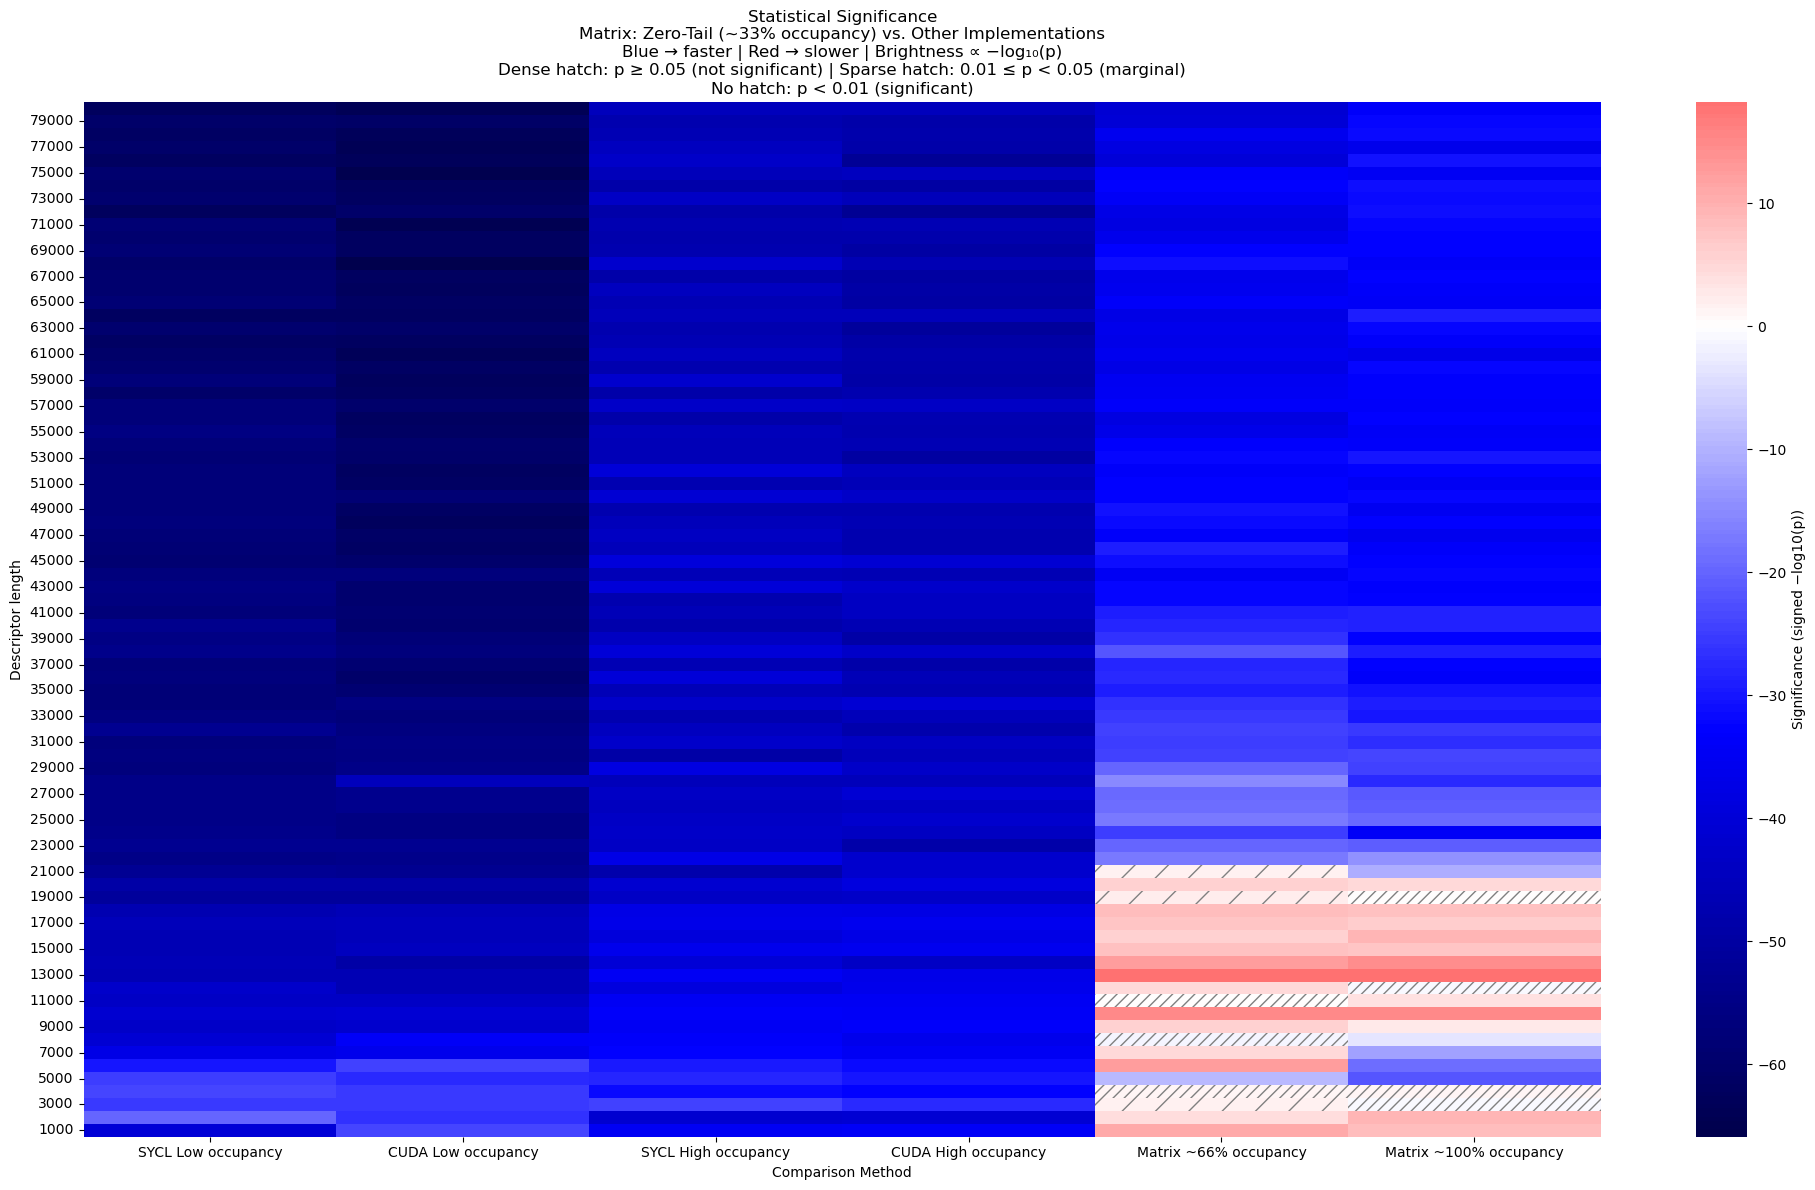

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle


# Assuming sig_df already exists (signed -log10(p) values)
threshold_05 = 1.3  # p ≈ 0.05
threshold_01 = 2    # p ≈ 0.01

fig, ax = plt.subplots(figsize=(20, 12))

# Main heatmap
sns.heatmap(
    sig_df,
    cmap='seismic',          # keep your original colormap
    center=0,                # 0 means no difference
    cbar_kws={'label': 'Significance (signed −log10(p))'},
    ax=ax
)

# Add hatching to non-significant cells
for i in range(sig_df.shape[0]):  # rows (cases)
    for j in range(sig_df.shape[1]):  # columns (methods)
        val = sig_df.iloc[i, j]
        if np.isnan(val) or abs(val) < threshold_01:
            rect = Rectangle(
                (j, i), 1, 1,
                fill=False,
                hatch=('///' if abs(val) < threshold_05 else "/"),           
                edgecolor='gray',
                linewidth=0.0
            )
            ax.add_patch(rect)


# ax.set_title(
#     'Statistical Significance\n'
#     'Matrix Zero Tail (~33% occupancy) vs Other Implementations\n'
#     'Blue→faster | Red→slower | Brightness∝−log₁₀(p) | Dense hatch: p≥0.05 | Sparse hatch 0.01>=p<0.05'
# )
ax.set_title(
    'Statistical Significance\n'
    'Matrix: Zero-Tail (~33% occupancy) vs. Other Implementations\n'
    'Blue → faster | Red → slower | Brightness ∝ −log₁₀(p)\n'
    'Dense hatch: p ≥ 0.05 (not significant) | Sparse hatch: 0.01 ≤ p < 0.05 (marginal)\n'
    'No hatch: p < 0.01 (significant)'
)
ax.set_xlabel('Comparison Method')
ax.set_ylabel('Descriptor length')

ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [79]:

# for i in range(sig_df.shape[0]):  # rows (cases)
#     for j in range(sig_df.shape[1]):  # columns (methods)
#         val = sig_df.iloc[i, j]
#         if np.isnan(val) or abs(val) < threshold:
#             rect = Rectangle(
#                 (j, i), 1, 1,
#                 fill=False,
#                 hatch='x',          # diagonal hatch
#                 edgecolor='gray',
#                 linewidth=0.0
#             )
#             ax.add_patch(rect)

# Labeling and orientation
# ax.set_title(f'Statistical Significance vs Matrix zero tail ~33% occupancy\n'
#              f'Blue: Matrix zero tail faster | Red: slower | Intensity: significance\n'
#              f'Hatched = not significant (p ≥ 0.05)')
# ax.set_title(
#     'Significance vs Matrix Zero Tail (~33% occupancy)\n'
#     'Blue→faster | Red→slower | Brightness∝significance | Hatched: p≥0.05'
# )

# ax.set_title(
#     'Statistical significance\n'
#     'Matrix Zero Tail (~33% occupancy) vs other implementations\n'
#     'Blue→faster | Red→slower | Brightness∝−log₁₀(p) | Hatched: not significant p≥0.05'
# )

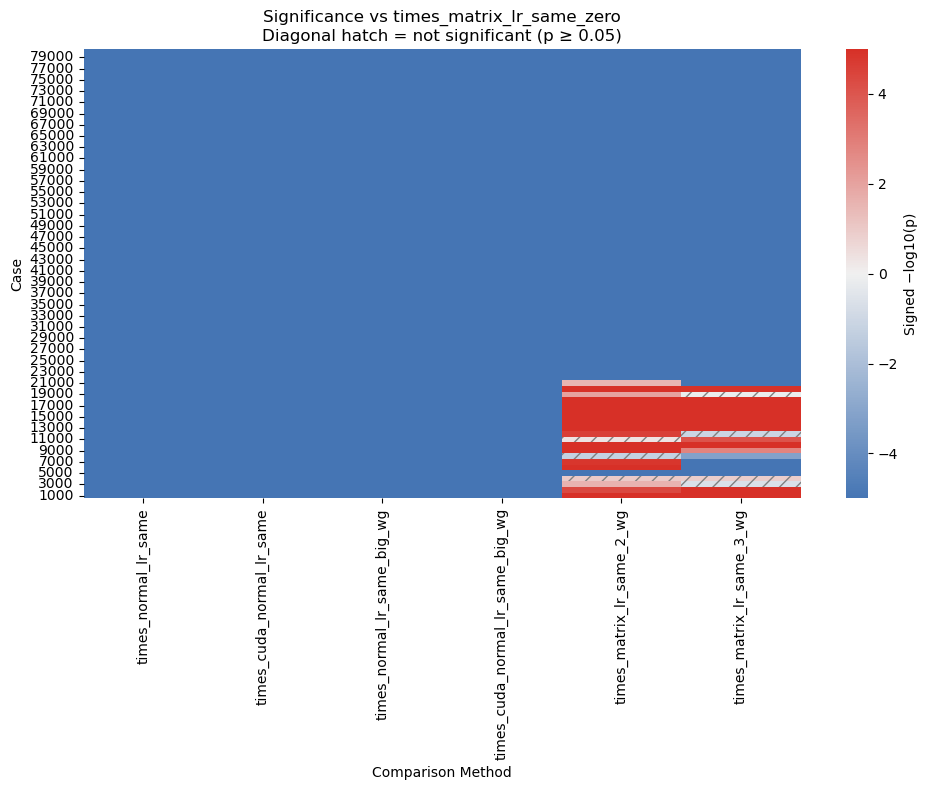

In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from scipy.stats import ttest_rel

# --- Example setup (replace with your own data) ---
baseline = 'times_matrix_lr_same_zero'
comparisons = [
    'times_normal_lr_same',
    'times_cuda_normal_lr_same',
    'times_normal_lr_same_big_wg',
    'times_cuda_normal_lr_same_big_wg',
    'times_matrix_lr_same_2_wg',
    'times_matrix_lr_same_3_wg'
]
cases = sorted(data['Case'].unique())

sig_matrix = np.zeros((len(cases), len(comparisons)))

for j, comp in enumerate(comparisons):
    for i, case in enumerate(cases):
        base = data[(data['Case']==case) & (data['Method']==baseline)]['Time']
        other = data[(data['Case']==case) & (data['Method']==comp)]['Time']
        if len(base) == len(other) and len(base) > 1:
            t, p = ttest_rel(base, other)
            diff = np.mean(base) - np.mean(other)
            sig_matrix[i, j] = np.sign(diff) * -np.log10(p)
        else:
            sig_matrix[i, j] = np.nan

sig_df = pd.DataFrame(sig_matrix, index=cases, columns=comparisons)

# --- Color setup ---
colors = [
    (0.0, "#4575b4"),  # blue = baseline faster
    (0.5, "#f0f0f0"),  # light gray = neutral
    (1.0, "#d73027"),  # red = baseline slower
]
custom_cmap = LinearSegmentedColormap.from_list("sigmap", [c for _, c in colors])
norm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sig_df.clip(-5, 5),
    cmap=custom_cmap,
    norm=norm,
    cbar_kws={'label': 'Signed −log10(p)'},
    ax=ax
)
ax.set_title(f'Significance vs {baseline}\nDiagonal hatch = not significant (p ≥ 0.05)')
ax.set_xlabel('Comparison Method')
ax.set_ylabel('Case')

# --- Overlay hatched rectangles for not significant cells ---
threshold = 1.3  # corresponds to p ≈ 0.05
for i in range(sig_df.shape[0]):  # cases
    for j in range(sig_df.shape[1]):  # methods
        val = sig_df.iloc[i, j]
        if np.isnan(val) or abs(val) < threshold:
            # Draw a hatched rectangle over the cell
            rect = Rectangle(
                (j, i), 1, 1,
                fill=False,
                hatch='//',
                edgecolor='gray',
                linewidth=0.0
            )
            ax.add_patch(rect)

# Optional: make y-axis go bottom-up
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from scipy.stats import ttest_rel

baseline = 'times_matrix_lr_same_zero'
comparisons = [
    'times_normal_lr_same',
    'times_cuda_normal_lr_same',
    'times_normal_lr_same_big_wg',
    'times_cuda_normal_lr_same_big_wg',
    'times_matrix_lr_same_2_wg',
    'times_matrix_lr_same_3_wg'
]

cases = sorted(data['Case'].unique())

sig_matrix = np.zeros((len(cases), len(comparisons)))

for j, comp in enumerate(comparisons):
    for i, case in enumerate(cases):
        base = data[(data['Case']==case) & (data['Method']==baseline)]['Time']
        other = data[(data['Case']==case) & (data['Method']==comp)]['Time']
        if len(base) == len(other) and len(base) > 1:
            t, p = ttest_rel(base, other)
            diff = np.mean(base) - np.mean(other)
            sig_matrix[i, j] = np.sign(diff) * -np.log10(p)
        else:
            sig_matrix[i, j] = np.nan

sig_df = pd.DataFrame(sig_matrix, index=cases, columns=comparisons)

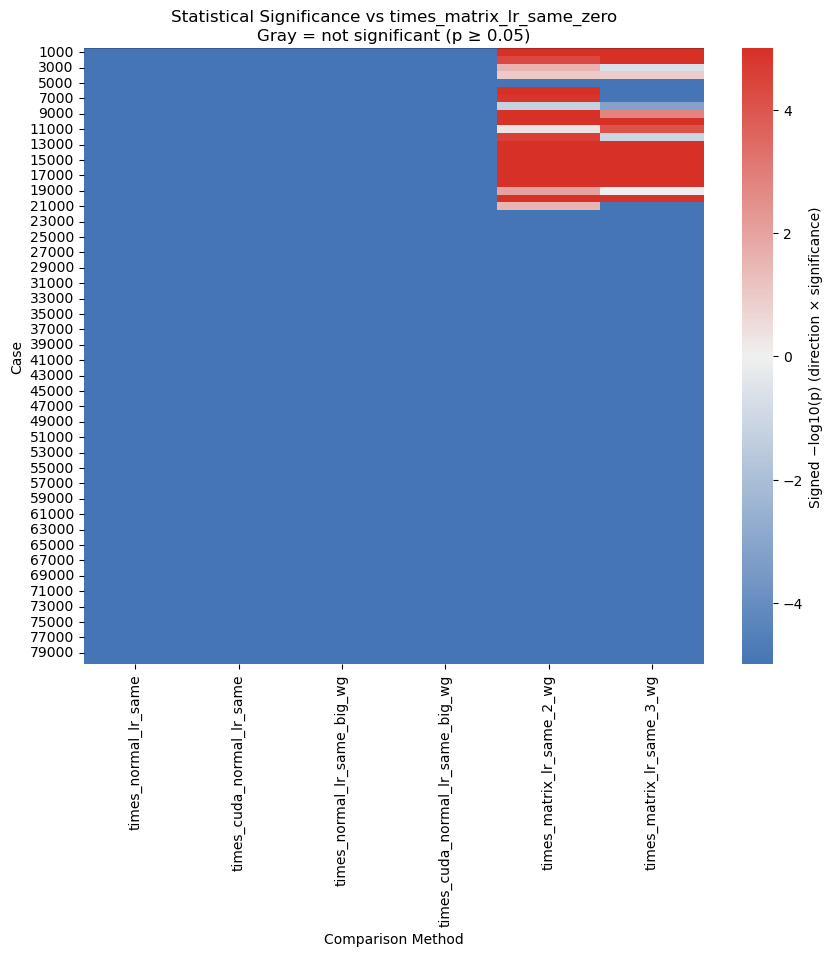

In [82]:
# Define color map: blue → gray → red
colors = [
    (0.0, "#4575b4"),  # blue (baseline faster)
    (0.5, "#f0f0f0"),  # light gray = not significant
    (1.0, "#d73027"),  # red (baseline slower)
]
custom_cmap = LinearSegmentedColormap.from_list("sigmap", [c for _, c in colors])

# Normalize: 0 at no difference, ±1.3 is roughly p=0.05 threshold
norm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)

plt.figure(figsize=(10, 8))
sns.heatmap(
    sig_df.clip(-5, 5),
    cmap=custom_cmap,
    norm=norm,
    cbar_kws={'label': 'Signed −log10(p) (direction × significance)'}
)
plt.axhline(y=0, color='black', linewidth=0.3)
plt.title(f'Statistical Significance vs {baseline}\nGray = not significant (p ≥ 0.05)')
plt.xlabel('Comparison Method')
plt.ylabel('Case')
plt.show()

<Axes: >

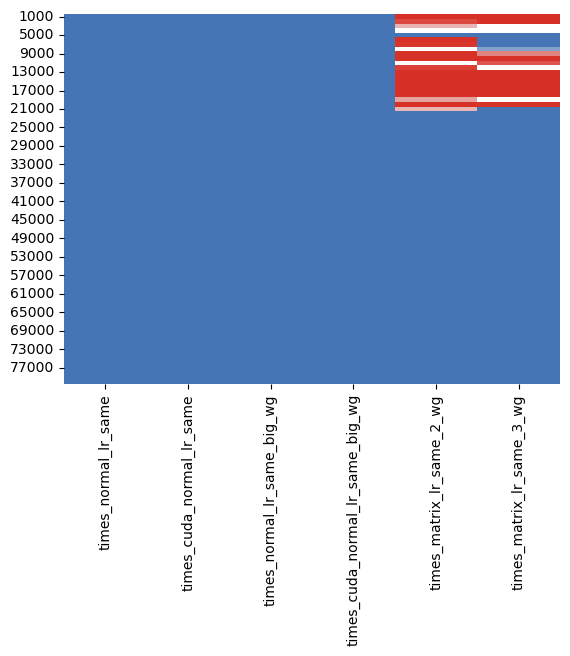

In [83]:
mask = sig_df.abs() < 1.3  # not significant region
sns.heatmap(
    sig_df.clip(-5, 5),
    cmap=custom_cmap,
    norm=norm,
    mask=mask,
    cbar=False
)

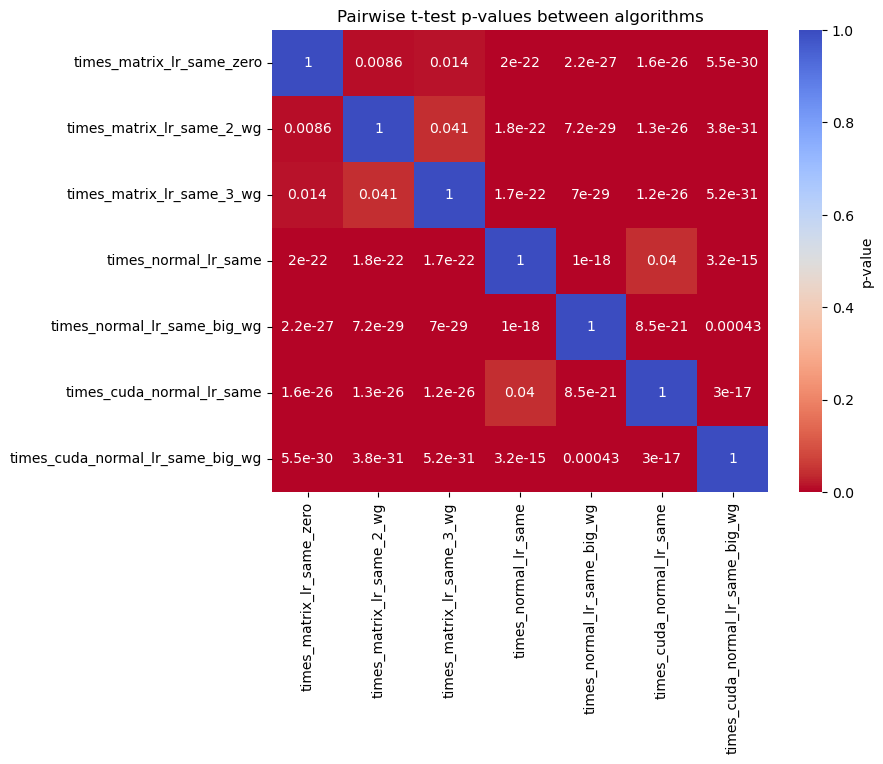

In [84]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

methods = data['Method'].unique()
n_methods = len(methods)
p_matrix = np.ones((n_methods, n_methods))

for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i < j:
            p_values = []
            for case in sorted(data['Case'].unique()):
                t1 = data[(data['Case']==case) & (data['Method']==m1)]['Time']
                t2 = data[(data['Case']==case) & (data['Method']==m2)]['Time']
                if len(t1) == len(t2) and len(t1) > 1:
                    _, p = ttest_rel(t1, t2)
                    p_values.append(p)
            mean_p = np.mean(p_values) if p_values else np.nan
            p_matrix[i, j] = mean_p
            p_matrix[j, i] = mean_p

p_df = pd.DataFrame(p_matrix, index=methods, columns=methods)

plt.figure(figsize=(8,6))
sns.heatmap(p_df, annot=True, cmap='coolwarm_r', cbar_kws={'label': 'p-value'})
plt.title('Pairwise t-test p-values between algorithms')
plt.show()

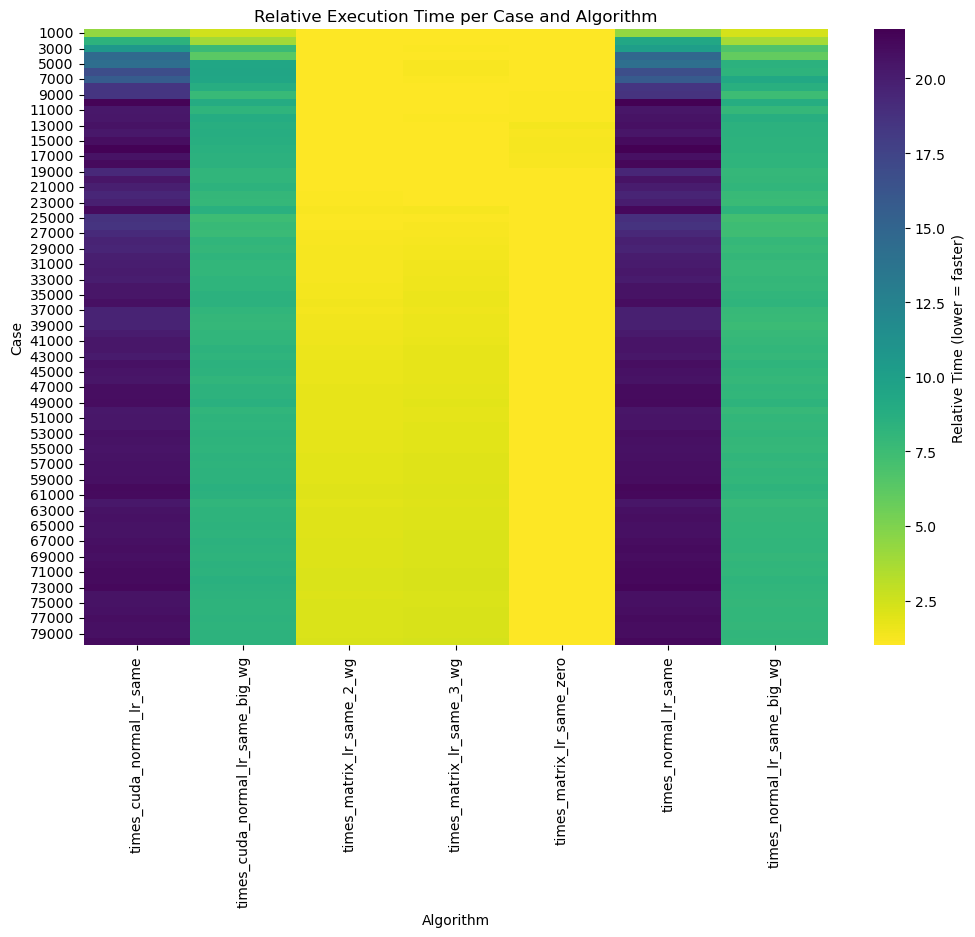

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Compute mean time per (Case, Method)
avg_time = data.groupby(['Case', 'Method'])['Time'].mean().reset_index()

# Normalize times within each case (relative to the min)
avg_time['RelTime'] = avg_time.groupby('Case')['Time'].transform(lambda x: x / x.min())

# Pivot for heatmap
pivot = avg_time.pivot(index='Case', columns='Method', values='RelTime')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='viridis_r', cbar_kws={'label': 'Relative Time (lower = faster)'})
plt.title('Relative Execution Time per Case and Algorithm')
plt.ylabel('Case')
plt.xlabel('Algorithm')
plt.show()

#### Start of Attempt to make scatter a function (but realised that I need to customize each most likely)

```python
def plot(a, std_a, b, std_b, p_vals, base, x, a_label, b_label, a_color, b_color, base_color, base_label, include_sig=True):
    plt.figure(figsize=(20, 12))
    if include_sig:
        for xi, p in zip(x, p_vals):
            color = significance_color(p)
            plt.axvspan(xi - 500, xi + 500, color=color, zorder=0)


        def color_square(color, edgecolor='gray', linewidth=0.8):
            da = DrawingArea(12, 12)
            da.add_artist(
                mpatches.Rectangle(
                    (0, 0), 12, 12,
                    fc=color,
                    ec=edgecolor,      
                    lw=linewidth,     
                    joinstyle='round'  
                )
            )
            return da

        box_opacity = 0.6
        green_box = color_square(significance_color(0.0001, box_opacity))
        yellow_box = color_square(significance_color(0.02, box_opacity))
        red_box = color_square(significance_color(0.1, box_opacity))

        box = VPacker(children=[
            HPacker(children=[green_box, TextArea("  p < 0.01  Significant", textprops={'color': 'gray', 'fontsize': 9})], align="center", pad=0, sep=4),
            HPacker(children=[yellow_box, TextArea("  0.01 ≤ p < 0.05  Moderate", textprops={'color': 'gray', 'fontsize': 9})], align="center", pad=0, sep=4),
            HPacker(children=[red_box, TextArea("  p ≥ 0.05  Not significant", textprops={'color': 'gray', 'fontsize': 9})], align="center", pad=0, sep=4)
        ], align="left", pad=0, sep=2)

        anchored_box = AnchoredOffsetbox(loc='lower right', child=box, pad=0.4,
                                        frameon=True, bbox_to_anchor=(0.98, 0.20),
                                        bbox_transform=plt.gca().transAxes,
                                        borderpad=0.4)
        frame = anchored_box.patch
        frame.set_edgecolor('gray')
        frame.set_linewidth(1.2)
        frame.set_facecolor('white')
        frame.set_alpha(1)
        frame.set_boxstyle("round,pad=0.3")
        plt.gca().add_artist(anchored_box)


    plt.scatter(x, a, label=a_label, color=intel_color, alpha=0.7)
    plt.scatter(x, b, label='Normal Matching CUDA low occupancy', color=nvidia_color, alpha=0.7)
    plt.scatter(x, mean_matrix_lr_zero, label='Matrix Matching SYCL', color=intel_color_dark, alpha=0.25, s=10)


    plt.text(0.98, 0.35,
            'Numbers next to points is Standard deviation in ms',
            transform=plt.gca().transAxes,
            ha='right', va='bottom', fontsize=9, color='gray')


    offsets = [(15, -15), (25, -25)]
    offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]

    for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_cuda_normal_lr_same, std_cuda_normal_lr_same), offsets):
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi - 5), 
            textcoords="offset points", 
            xytext=(dx,dy - 3),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )


    offsets_sycl = [(-15, 15), (-25, 25)]
    offsets_sycl = (offsets_sycl * ((len(x_scatter) // len(offsets_sycl)) + 1))[:len(x_scatter)]

    for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_normal_lr_same, std_normal_lr_same), offsets_sycl):
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi - 5), 
            textcoords="offset points", 
            xytext=(dx,dy - 3),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color, lw=0.5, alpha=0.7)
        )

    plt.xlabel('Query and Right Descriptor Length')
    plt.ylabel('Time (ms)')
    plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
    plt.legend()
    plt.show()

```